# PSF Interpolation Validation

This notebook validates the PSF interpolation accuracy for the Roman grism disperser.

**Goal**: Compare interpolated PSFs from precomputed grids against direct STPSF calculations
at random test positions to quantify interpolation errors.

**Metrics**:
- Total flux error: `|interp.sum() - direct.sum()| / direct.sum()`
- Mean absolute error (MAE) per radial bin
- Fractional error (MAE / PSF) per radial bin

**Test Points**: 128 Sobol sequence points in (x, y, λ) space for uniform coverage

**Configurations Tested**:
- 5×5 spatial grid, 0.1 μm wavelength spacing
- 5×5 spatial grid, 0.05 μm wavelength spacing
- 10×10 spatial grid, 0.1 μm wavelength spacing
- 3×3 spatial grid, 0.02 μm wavelength spacing
- **4×4 spatial grid, 0.02 μm wavelength spacing (recommended)**

**Key Findings**:
- Wavelength sampling dominates wing accuracy (fine λ reduces errors at large radii)
- Spatial grid matters for core accuracy (3×3 too coarse, 4×4 sufficient)
- **Recommended: 4×4 spatial + 0.02 μm wavelength** - best balance of accuracy across all radii
  - 896 PSFs, 121 MB memory, 5.5 min generation time
  - <0.002% max flux error, <5% fractional error at all radii

**References**:
- Design: `docs/psf_phase1_plan.md`, `docs/star_dispersion.md`
- Implementation: `src/roman_disperser/psf_model.py`, `src/roman_disperser/psf_utils.py`
- Tests: `tests/test_psf_model.py`
- STPSF docs: `docs/stpsf.md` (quick reference), `docs/stpsf_full.md` (comprehensive)

## Setup

In [43]:
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, SymLogNorm
import pandas as pd
from scipy.stats import qmc

import jax.numpy as jnp
import stpsf.roman

from roman_disperser import psf_model, psf_utils

# Suppress STPSF warnings about field points outside reference data
warnings.filterwarnings('ignore', message='.*outside the range of the reference data.*')

plt.rcParams['font.size'] = 11
plt.rcParams['figure.facecolor'] = 'white'

In [44]:
# ============================================================================
# CONFIGURATION
# ============================================================================

# Detector for detailed validation
DETECTOR = 'WFI02'
ORDER = '1'  # GRISM1 (first order, dispersed)

# PSF parameters (must match psf_model.py defaults)
FOV_ARCSEC = 5.0
OVERSAMPLE = 4
PIXEL_SCALE = 0.11  # arcsec/pixel (Roman WFI native)
PSF_PIXEL_SCALE = PIXEL_SCALE / OVERSAMPLE  # oversampled pixel scale

# Test point ranges
X_RANGE = (1.0, 4088.0)  # SCA x-coordinates (FITS 1-indexed)
Y_RANGE = (1.0, 4088.0)  # SCA y-coordinates
WL_RANGE = (0.9e-6, 2.0e-6)  # Wavelength range in meters

# Number of Sobol test points
N_TEST_POINTS = 128

# Radial binning for error analysis
RADIAL_BIN_SIZE = 0.1  # arcsec
RADIAL_MAX = 2.0  # arcsec (covers ~EE95 at longest wavelength)

print("Configuration:")
print(f"  Detector: {DETECTOR}")
print(f"  Order: {ORDER} (GRISM1)")
print(f"  FOV: {FOV_ARCSEC} arcsec")
print(f"  Oversample: {OVERSAMPLE}×")
print(f"  Test points: {N_TEST_POINTS} (Sobol sequence)")
print(f"  X range: {X_RANGE}")
print(f"  Y range: {Y_RANGE}")
print(f"  Wavelength range: {WL_RANGE[0]*1e6:.1f} - {WL_RANGE[1]*1e6:.1f} μm")
print(f"  Radial bins: {RADIAL_BIN_SIZE} arcsec, max {RADIAL_MAX} arcsec")

Configuration:
  Detector: WFI02
  Order: 1 (GRISM1)
  FOV: 5.0 arcsec
  Oversample: 4×
  Test points: 128 (Sobol sequence)
  X range: (1.0, 4088.0)
  Y range: (1.0, 4088.0)
  Wavelength range: 0.9 - 2.0 μm
  Radial bins: 0.1 arcsec, max 2.0 arcsec


## Generate Sobol Test Points

Sobol sequences provide quasi-random points with better uniformity than
pseudo-random sequences, ensuring good coverage of the (x, y, λ) parameter space.

In [45]:
def generate_sobol_test_points(n_points, x_range, y_range, wl_range, seed=42):
    """
    Generate Sobol sequence test points in (x, y, wavelength) space.
    
    Parameters
    ----------
    n_points : int
        Number of test points
    x_range, y_range : tuple
        (min, max) for SCA coordinates
    wl_range : tuple
        (min, max) for wavelength in meters
    seed : int
        Random seed for scrambling
    
    Returns
    -------
    x_test, y_test, wl_test : ndarray
        Test coordinates
    """
    sampler = qmc.Sobol(d=3, scramble=True, seed=seed)
    points = sampler.random(n_points)  # [n_points, 3] in [0, 1]
    
    # Scale to actual ranges
    x_test = x_range[0] + points[:, 0] * (x_range[1] - x_range[0])
    y_test = y_range[0] + points[:, 1] * (y_range[1] - y_range[0])
    wl_test = wl_range[0] + points[:, 2] * (wl_range[1] - wl_range[0])
    
    return x_test, y_test, wl_test


# Generate test points
x_test, y_test, wl_test = generate_sobol_test_points(
    N_TEST_POINTS, X_RANGE, Y_RANGE, WL_RANGE
)

print(f"Generated {N_TEST_POINTS} Sobol test points")
print(f"  x: [{x_test.min():.1f}, {x_test.max():.1f}]")
print(f"  y: [{y_test.min():.1f}, {y_test.max():.1f}]")
print(f"  λ: [{wl_test.min()*1e6:.3f}, {wl_test.max()*1e6:.3f}] μm")

Generated 128 Sobol test points
  x: [5.6, 4079.9]
  y: [21.0, 4083.2]
  λ: [0.904, 1.993] μm


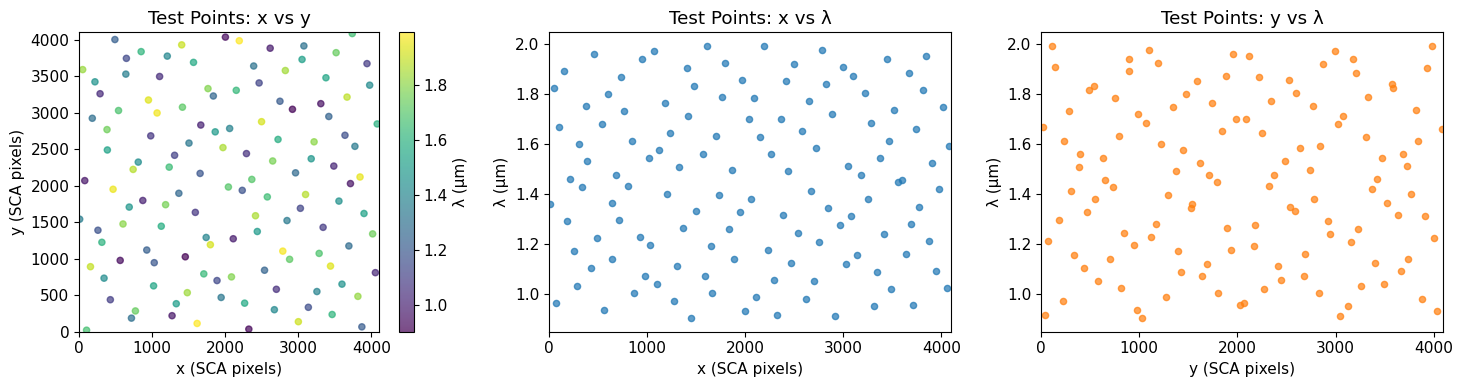

In [46]:
# Visualize test point distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# x vs y
ax = axes[0]
sc = ax.scatter(x_test, y_test, c=wl_test*1e6, cmap='viridis', s=20, alpha=0.7)
ax.set_xlabel('x (SCA pixels)')
ax.set_ylabel('y (SCA pixels)')
ax.set_title('Test Points: x vs y')
ax.set_xlim(0, 4100)
ax.set_ylim(0, 4100)
ax.set_aspect('equal')
plt.colorbar(sc, ax=ax, label='λ (μm)')

# x vs wavelength
ax = axes[1]
ax.scatter(x_test, wl_test*1e6, c='tab:blue', s=20, alpha=0.7)
ax.set_xlabel('x (SCA pixels)')
ax.set_ylabel('λ (μm)')
ax.set_title('Test Points: x vs λ')
ax.set_xlim(0, 4100)

# y vs wavelength
ax = axes[2]
ax.scatter(y_test, wl_test*1e6, c='tab:orange', s=20, alpha=0.7)
ax.set_xlabel('y (SCA pixels)')
ax.set_ylabel('λ (μm)')
ax.set_title('Test Points: y vs λ')
ax.set_xlim(0, 4100)

plt.tight_layout()
plt.show()

## Helper Functions

In [47]:
def compute_direct_psf(wfi, xsca, ysca, wavelength, fov_arcsec, oversample):
    """
    Compute PSF directly from STPSF at given position and wavelength.
    
    Parameters
    ----------
    wfi : stpsf.roman.WFI
        Pre-configured STPSF WFI object
    xsca, ysca : float
        SCA coordinates (FITS 1-indexed)
    wavelength : float
        Wavelength in meters
    fov_arcsec : float
        Field of view in arcseconds
    oversample : int
        Oversampling factor
    
    Returns
    -------
    psf : ndarray
        PSF array (OVERDIST extension)
    """
    # Convert SCA to STPSF coordinates
    x_stpsf, y_stpsf = psf_utils.sca_to_stpsf_position(float(xsca), float(ysca))
    wfi.detector_position = (float(x_stpsf), float(y_stpsf))
    
    # Calculate PSF
    psf_hdu = wfi.calc_psf(
        monochromatic=float(wavelength),
        fov_arcsec=fov_arcsec,
        oversample=oversample
    )
    
    return psf_hdu['OVERDIST'].data


def compute_radial_bins(psf_shape, pixel_scale, bin_size, max_radius):
    """
    Compute radial bin indices for a PSF array.
    
    Parameters
    ----------
    psf_shape : tuple
        Shape of PSF array (ny, nx)
    pixel_scale : float
        Pixel scale in arcsec/pixel
    bin_size : float
        Radial bin size in arcsec
    max_radius : float
        Maximum radius in arcsec
    
    Returns
    -------
    bin_indices : ndarray
        Bin index for each pixel (-1 for pixels beyond max_radius)
    bin_edges : ndarray
        Bin edges in arcsec
    """
    ny, nx = psf_shape
    cy, cx = (ny - 1) / 2.0, (nx - 1) / 2.0
    
    y, x = np.mgrid[0:ny, 0:nx]
    r_arcsec = np.sqrt((x - cx)**2 + (y - cy)**2) * pixel_scale
    
    # Create bin edges
    n_bins = int(np.ceil(max_radius / bin_size))
    bin_edges = np.linspace(0, max_radius, n_bins + 1)
    
    # Assign bin indices
    bin_indices = np.digitize(r_arcsec, bin_edges) - 1
    bin_indices[r_arcsec > max_radius] = -1  # Mark pixels beyond max_radius
    
    return bin_indices, bin_edges


def compute_radial_mae(psf_interp, psf_direct, bin_indices, n_bins):
    """
    Compute mean absolute error and mean PSF value per radial bin.

    Parameters
    ----------
    psf_interp : ndarray
        Interpolated PSF
    psf_direct : ndarray
        Direct STPSF PSF
    bin_indices : ndarray
        Bin index for each pixel
    n_bins : int
        Number of radial bins

    Returns
    -------
    mae_per_bin : ndarray
        Mean absolute error for each bin
    psf_per_bin : ndarray
        Mean PSF value (from direct PSF) for each bin
    n_pixels_per_bin : ndarray
        Number of pixels in each bin
    """
    abs_error = np.abs(np.asarray(psf_interp) - np.asarray(psf_direct))
    psf_direct_arr = np.asarray(psf_direct)

    mae_per_bin = np.zeros(n_bins)
    psf_per_bin = np.zeros(n_bins)
    n_pixels_per_bin = np.zeros(n_bins, dtype=int)

    for i in range(n_bins):
        mask = bin_indices == i
        if mask.sum() > 0:
            mae_per_bin[i] = abs_error[mask].mean()
            psf_per_bin[i] = psf_direct_arr[mask].mean()
            n_pixels_per_bin[i] = mask.sum()

    return mae_per_bin, psf_per_bin, n_pixels_per_bin


print("Helper functions defined.")

Helper functions defined.


## Validation Function

In [48]:
def validate_interpolation(
    payload,
    x_test, y_test, wl_test,
    detector, order,
    fov_arcsec, oversample,
    radial_bin_size, radial_max,
    verbose=True
):
    """
    Validate PSF interpolation against direct STPSF calculations.
    
    Parameters
    ----------
    payload : dict
        PSF payload from psf_model.make_psf_payload()
    x_test, y_test, wl_test : ndarray
        Test coordinates (SCA x, y in pixels; wavelength in meters)
    detector : str
        Detector name (e.g., 'WFI02')
    order : str
        Spectral order ('0' or '1')
    fov_arcsec : float
        PSF field of view in arcseconds
    oversample : int
        PSF oversampling factor
    radial_bin_size : float
        Radial bin size in arcsec
    radial_max : float
        Maximum radius for binning in arcsec
    verbose : bool
        Print progress
    
    Returns
    -------
    results : dict
        Validation results containing:
        - 'flux_errors': fractional flux errors for each test point
        - 'mae_per_bin': mean absolute error per radial bin (averaged over test points)
        - 'psf_per_bin': mean PSF value per radial bin (averaged over test points)
        - 'bin_edges': radial bin edges
        - 'test_coords': test coordinates
        - 'timing': timing information
    """
    n_test = len(x_test)
    pixel_scale = 0.11 / oversample  # oversampled pixel scale
    
    # Initialize STPSF
    filter_map = {'0': 'GRISM0', '1': 'GRISM1'}
    wfi = stpsf.roman.WFI()
    wfi.filter = filter_map[order]
    wfi.detector = detector
    
    # Storage
    flux_errors = []
    all_mae_per_bin = []
    all_psf_per_bin = []
    bin_indices = None
    bin_edges = None
    n_bins = None
    
    t_interp_total = 0
    t_direct_total = 0
    t_start = time.time()
    
    for i in range(n_test):
        x, y, wl = x_test[i], y_test[i], wl_test[i]
        
        # Interpolated PSF
        t0 = time.time()
        psf_interp = psf_model.interpolate_psf(payload, float(x), float(y), float(wl))
        psf_interp = np.asarray(psf_interp)
        t_interp_total += time.time() - t0
        
        # Direct STPSF PSF
        t0 = time.time()
        psf_direct = compute_direct_psf(wfi, x, y, wl, fov_arcsec, oversample)
        t_direct_total += time.time() - t0
        
        # Ensure same shape (should match, but check)
        if psf_interp.shape != psf_direct.shape:
            raise ValueError(f"Shape mismatch: interp {psf_interp.shape} vs direct {psf_direct.shape}")
        
        # Compute radial bins (once, using first PSF shape)
        if bin_indices is None:
            bin_indices, bin_edges = compute_radial_bins(
                psf_direct.shape, pixel_scale, radial_bin_size, radial_max
            )
            n_bins = len(bin_edges) - 1
        
        # Total flux error
        flux_interp = psf_interp.sum()
        flux_direct = psf_direct.sum()
        flux_error = abs(flux_interp - flux_direct) / flux_direct
        flux_errors.append(flux_error)
        
        # Radial MAE and PSF profile
        mae_per_bin, psf_per_bin, _ = compute_radial_mae(psf_interp, psf_direct, bin_indices, n_bins)
        all_mae_per_bin.append(mae_per_bin)
        all_psf_per_bin.append(psf_per_bin)
        
        if verbose and (i + 1) % 16 == 0:
            elapsed = time.time() - t_start
            rate = (i + 1) / elapsed
            eta = (n_test - i - 1) / rate
            print(f"  [{i+1}/{n_test}] flux_err={flux_error:.2e}, "
                  f"elapsed={elapsed:.1f}s, ETA={eta:.1f}s")
    
    t_total = time.time() - t_start
    
    # Average MAE and PSF per bin across all test points
    all_mae_per_bin = np.array(all_mae_per_bin)
    all_psf_per_bin = np.array(all_psf_per_bin)
    mean_mae_per_bin = all_mae_per_bin.mean(axis=0)
    std_mae_per_bin = all_mae_per_bin.std(axis=0)
    mean_psf_per_bin = all_psf_per_bin.mean(axis=0)
    
    results = {
        'flux_errors': np.array(flux_errors),
        'mae_per_bin_all': all_mae_per_bin,
        'mean_mae_per_bin': mean_mae_per_bin,
        'std_mae_per_bin': std_mae_per_bin,
        'mean_psf_per_bin': mean_psf_per_bin,
        'bin_edges': bin_edges,
        'test_coords': {
            'x': x_test,
            'y': y_test,
            'wavelength': wl_test
        },
        'timing': {
            'total': t_total,
            'interp_total': t_interp_total,
            'direct_total': t_direct_total,
            'per_point': t_total / n_test,
            'interp_per_point': t_interp_total / n_test,
            'direct_per_point': t_direct_total / n_test,
        }
    }
    
    if verbose:
        print(f"\nValidation complete:")
        print(f"  Total time: {t_total:.1f}s ({t_total/n_test:.2f}s per point)")
        print(f"  Interpolation time: {t_interp_total:.3f}s ({t_interp_total/n_test*1000:.2f}ms per point)")
        print(f"  Direct STPSF time: {t_direct_total:.1f}s ({t_direct_total/n_test:.2f}s per point)")
        print(f"  Flux error: mean={np.mean(flux_errors):.2e}, max={np.max(flux_errors):.2e}")
    
    return results


print("Validation function defined.")

Validation function defined.


## Visualization Functions

In [49]:
def plot_validation_results(results, title=''):
    """
    Plot validation results: flux errors, radial MAE, PSF profile, and fractional error.
    
    Parameters
    ----------
    results : dict
        Results from validate_interpolation()
    title : str
        Overall figure title (e.g., configuration name)
    """
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    
    # 1. Flux error histogram
    ax = axes[0, 0]
    flux_errors = results['flux_errors']
    ax.hist(flux_errors * 100, bins=30, edgecolor='black', alpha=0.7)
    ax.axvline(np.mean(flux_errors) * 100, color='red', linestyle='--', 
               label=f'Mean: {np.mean(flux_errors)*100:.3f}%')
    ax.axvline(np.median(flux_errors) * 100, color='orange', linestyle=':', 
               label=f'Median: {np.median(flux_errors)*100:.3f}%')
    ax.set_xlabel('Flux Error (%)')
    ax.set_ylabel('Count')
    ax.set_title('Total Flux Error Distribution')
    ax.legend()
    ax.grid(alpha=0.3)
    
    # 2. Flux error vs wavelength
    ax = axes[0, 1]
    wl_um = results['test_coords']['wavelength'] * 1e6
    ax.scatter(wl_um, flux_errors * 100, alpha=0.6, s=20)
    ax.set_xlabel('Wavelength (μm)')
    ax.set_ylabel('Flux Error (%)')
    ax.set_title('Flux Error vs Wavelength')
    ax.grid(alpha=0.3)
    
    # 3. Flux error spatial distribution
    ax = axes[0, 2]
    x = results['test_coords']['x']
    y = results['test_coords']['y']
    sc = ax.scatter(x, y, c=flux_errors * 100, cmap='viridis', s=30, alpha=0.7)
    plt.colorbar(sc, ax=ax, label='Flux Error (%)')
    ax.set_xlabel('x (SCA pixels)')
    ax.set_ylabel('y (SCA pixels)')
    ax.set_title('Flux Error Spatial Distribution')
    ax.set_xlim(0, 4100)
    ax.set_ylim(0, 4100)
    ax.set_aspect('equal')
    
    # Get radial bin data
    bin_edges = results['bin_edges']
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    mean_mae = results['mean_mae_per_bin']
    std_mae = results['std_mae_per_bin']
    mean_psf = results['mean_psf_per_bin']
    
    # 4. Radial MAE
    ax = axes[1, 0]
    ax.errorbar(bin_centers, mean_mae, yerr=std_mae, fmt='o-', capsize=3, 
                markersize=4, color='tab:blue', label='MAE (Mean ± Std)')
    ax.set_xlabel('Radius (arcsec)')
    ax.set_ylabel('Mean Absolute Error')
    ax.set_title('Radial MAE')
    ax.set_yscale('log')
    ax.grid(alpha=0.3)
    ax.legend()
    
    # 5. PSF radial profile
    ax = axes[1, 1]
    ax.plot(bin_centers, mean_psf, 's-', color='tab:orange', markersize=4, label='Mean PSF Value')
    ax.set_xlabel('Radius (arcsec)')
    ax.set_ylabel('Mean PSF Value')
    ax.set_title('PSF Radial Profile')
    ax.set_yscale('log')
    ax.grid(alpha=0.3)
    ax.legend()
    
    # 6. Fractional error (MAE / PSF ratio)
    ax = axes[1, 2]
    threshold = 1e-8
    frac_error = np.where(mean_psf > threshold, mean_mae / mean_psf, np.nan)
    ax.plot(bin_centers, frac_error * 100, 'o-', color='tab:green', markersize=4)
    ax.set_xlabel('Radius (arcsec)')
    ax.set_ylabel('Fractional Error (MAE / PSF) [%]')
    ax.set_title('Fractional Error per Radial Bin')
    ax.set_yscale('log')
    ax.grid(alpha=0.3)
    
    # Add overall figure title
    if title:
        fig.suptitle(title, fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return fig


def print_summary_stats(results, config_name):
    """
    Print summary statistics for validation results.
    
    Parameters
    ----------
    results : dict
        Results from validate_interpolation()
    config_name : str
        Name of the configuration
    """
    flux_errors = results['flux_errors']
    mean_mae = results['mean_mae_per_bin']
    timing = results['timing']
    
    print(f"\n{'='*60}")
    print(f"Summary: {config_name}")
    print(f"{'='*60}")
    
    print(f"\nFlux Error Statistics:")
    print(f"  Mean:   {np.mean(flux_errors)*100:.4f}%")
    print(f"  Median: {np.median(flux_errors)*100:.4f}%")
    print(f"  Std:    {np.std(flux_errors)*100:.4f}%")
    print(f"  Max:    {np.max(flux_errors)*100:.4f}%")
    print(f"  Min:    {np.min(flux_errors)*100:.4f}%")
    
    print(f"\nRadial MAE Statistics (across all bins):")
    print(f"  Mean MAE:   {np.mean(mean_mae):.2e}")
    print(f"  Max MAE:    {np.max(mean_mae):.2e}")
    print(f"  Min MAE:    {np.min(mean_mae):.2e}")
    
    print(f"\nTiming:")
    print(f"  Total validation: {timing['total']:.1f}s")
    print(f"  Per test point:   {timing['per_point']:.2f}s")
    print(f"  Interpolation:    {timing['interp_per_point']*1000:.2f}ms per point")
    print(f"  Direct STPSF:     {timing['direct_per_point']:.2f}s per point")
    print(f"  Speedup:          {timing['direct_per_point']/timing['interp_per_point']:.0f}×")


print("Visualization functions defined.")

Visualization functions defined.


---

# Configuration 1: 5×5 Spatial Grid, 0.1 μm Wavelength Spacing

This is the coarsest grid configuration, useful for fast iteration.

In [50]:
# Configuration 1: 5×5 spatial, 0.1 μm wavelength spacing
CONFIG1_NAME = "5×5 spatial, 0.1 μm wavelength"

# Wavelengths: 0.9 to 2.0 μm in 0.1 μm steps = 12 wavelengths
wavelengths_config1 = np.arange(0.9e-6, 2.01e-6, 0.1e-6)
print(f"Wavelengths: {len(wavelengths_config1)} points")
print(f"  Range: {wavelengths_config1[0]*1e6:.1f} - {wavelengths_config1[-1]*1e6:.1f} μm")

# Spatial grid: 5×5
spatial_grid_config1 = {
    'x': np.linspace(1, 4088, 5),
    'y': np.linspace(1, 4088, 5)
}
print(f"Spatial grid: {len(spatial_grid_config1['x'])}×{len(spatial_grid_config1['y'])}")

n_psfs = len(wavelengths_config1) * len(spatial_grid_config1['x']) * len(spatial_grid_config1['y'])
print(f"Total PSFs to generate: {n_psfs}")

Wavelengths: 12 points
  Range: 0.9 - 2.0 μm
Spatial grid: 5×5
Total PSFs to generate: 300


In [51]:
# Generate PSF payload for Configuration 1
print(f"Generating PSF payload: {CONFIG1_NAME}")
print(f"Detector: {DETECTOR}, Order: {ORDER}")
print()

t_start = time.time()
payload_config1 = psf_model.make_psf_payload(
    detector=DETECTOR,
    order=ORDER,
    wavelengths=wavelengths_config1,
    spatial_grid=spatial_grid_config1,
    fov_arcsec=FOV_ARCSEC,
    oversample=OVERSAMPLE,
    verbose=True
)
t_payload1 = time.time() - t_start

print(f"\nPayload generation time: {t_payload1:.1f}s ({t_payload1/60:.1f} min)")
print(f"PSF grid shape: {payload_config1['psf_grid'].shape}")
print(f"Memory: {payload_config1['psf_grid'].nbytes / 1e6:.1f} MB")

Generating PSF payload: 5×5 spatial, 0.1 μm wavelength
Detector: WFI02, Order: 1

Generating PSF grid for WFI02, order 1...
  Spatial grid: 5×5 positions
  Wavelengths: 12 samples (0.90-2.00 μm)
  Total PSFs: 300
  FOV: 5.0 arcsec, Oversample: 4×
  This may take 30-60 minutes...


Attempted to get aberrations at wavelength 9e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at field point (4, 4) which is outside the range of the reference data; approximating to nearest interpolated point (38.88344255570929, 4.0086323787566585)
Attempted to get aberrations at field point (4, 4) which is outside the range of the reference data; approximating to nearest interpolated point (38.88344255570929, 4.0086323787566

  Progress: 10/25 positions (40.0%), ETA: 1.1 min


Attempted to get aberrations at field point (4, 2047) which is outside the range of the reference data; approximating to nearest interpolated point (38.37787465793884, 2047.0085072691556)
Attempted to get aberrations at field point (4, 2047) which is outside the range of the reference data; approximating to nearest interpolated point (38.37787465793884, 2047.0085072691556)
Attempted to get aberrations at field point (4, 2047) which is outside the range of the reference data; approximating to nearest interpolated point (38.37787465793884, 2047.0085072691556)
Attempted to get aberrations at field point (4, 2047) which is outside the range of the reference data; approximating to nearest interpolated point (38.37787465793884, 2047.0085072691556)
Attempted to get aberrations at field point (4, 2047) which is outside the range of the reference data; approximating to nearest interpolated point (38.37787465793884, 2047.0085072691556)
Attempted to get aberrations at field point (4, 2047) which 

  Progress: 20/25 positions (80.0%), ETA: 0.4 min


Attempted to get aberrations at field point (4, 4091) which is outside the range of the reference data; approximating to nearest input grid point
Attempted to get aberrations at field point (4, 4091) which is outside the range of the reference data; approximating to nearest input grid point
Attempted to get aberrations at field point (4, 4091) which is outside the range of the reference data; approximating to nearest input grid point
Attempted to get aberrations at field point (4, 4091) which is outside the range of the reference data; approximating to nearest input grid point
Attempted to get aberrations at field point (4, 4091) which is outside the range of the reference data; approximating to nearest input grid point
Attempted to get aberrations at field point (4, 4091) which is outside the range of the reference data; approximating to nearest input grid point
Attempted to get aberrations at field point (4, 4091) which is outside the range of the reference data; approximating to nea


PSF grid generation complete:
  Total time: 107.8 seconds (1.8 minutes)
  Time per PSF: 0.36 seconds
  Total PSFs calculated: 300

PSF payload created:
  PSF grid shape: (12, 5, 5, 184, 184)
  Memory usage: 40.6 MB
  Timing: 107.8s (1.8 min)

Payload generation time: 107.8s (1.8 min)
PSF grid shape: (12, 5, 5, 184, 184)
Memory: 40.6 MB


In [52]:
# Validate Configuration 1
print(f"\nValidating: {CONFIG1_NAME}")
print(f"Test points: {N_TEST_POINTS}")
print()

results_config1 = validate_interpolation(
    payload_config1,
    x_test, y_test, wl_test,
    DETECTOR, ORDER,
    FOV_ARCSEC, OVERSAMPLE,
    RADIAL_BIN_SIZE, RADIAL_MAX,
    verbose=True
)


Validating: 5×5 spatial, 0.1 μm wavelength
Test points: 128



Attempted to get aberrations at wavelength 9.4e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.4e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.4e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.4e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.4e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at field point (3943, 3674) which is outside the range of the reference data; approximating to nearest interpolated point (3942.9493592322137, 3572.0601344464817)
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wa

  [16/128] flux_err=5.87e-06, elapsed=5.8s, ETA=40.4s


Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at field point (2194, 3987) which is outside the range of the reference data; approximating to nearest interpolated point (2193.79430157175, 3572.9290639336455)
Attempted to get aberrations at field point (1208, 3777) which is outside the range of the reference data; approximating to nearest interpolated point (1207.89886678

  [32/128] flux_err=6.07e-06, elapsed=11.6s, ETA=34.7s


...

  [96/128] flux_err=2.27e-05, elapsed=35.2s, ETA=11.7s


Attempted to get aberrations at wavelength 9.7e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.7e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.7e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.7e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.7e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.8e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.8e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.8e-07 outside the range of the reference data; clipp

  [112/128] flux_err=1.05e-04, elapsed=41.1s, ETA=5.9s


Attempted to get aberrations at field point (490, 4004) which is outside the range of the reference data; approximating to nearest interpolated point (489.78627698245634, 3573.7755656845593)
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 9.2e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wav

  [128/128] flux_err=4.72e-06, elapsed=46.8s, ETA=0.0s

Validation complete:
  Total time: 46.8s (0.37s per point)
  Interpolation time: 0.474s (3.70ms per point)
  Direct STPSF time: 46.2s (0.36s per point)
  Flux error: mean=3.56e-05, max=1.22e-04



Summary: 5×5 spatial, 0.1 μm wavelength

Flux Error Statistics:
  Mean:   0.0036%
  Median: 0.0026%
  Std:    0.0031%
  Max:    0.0122%
  Min:    0.0000%

Radial MAE Statistics (across all bins):
  Mean MAE:   4.81e-06
  Max MAE:    2.54e-05
  Min MAE:    6.51e-07

Timing:
  Total validation: 46.8s
  Per test point:   0.37s
  Interpolation:    3.70ms per point
  Direct STPSF:     0.36s per point
  Speedup:          97×


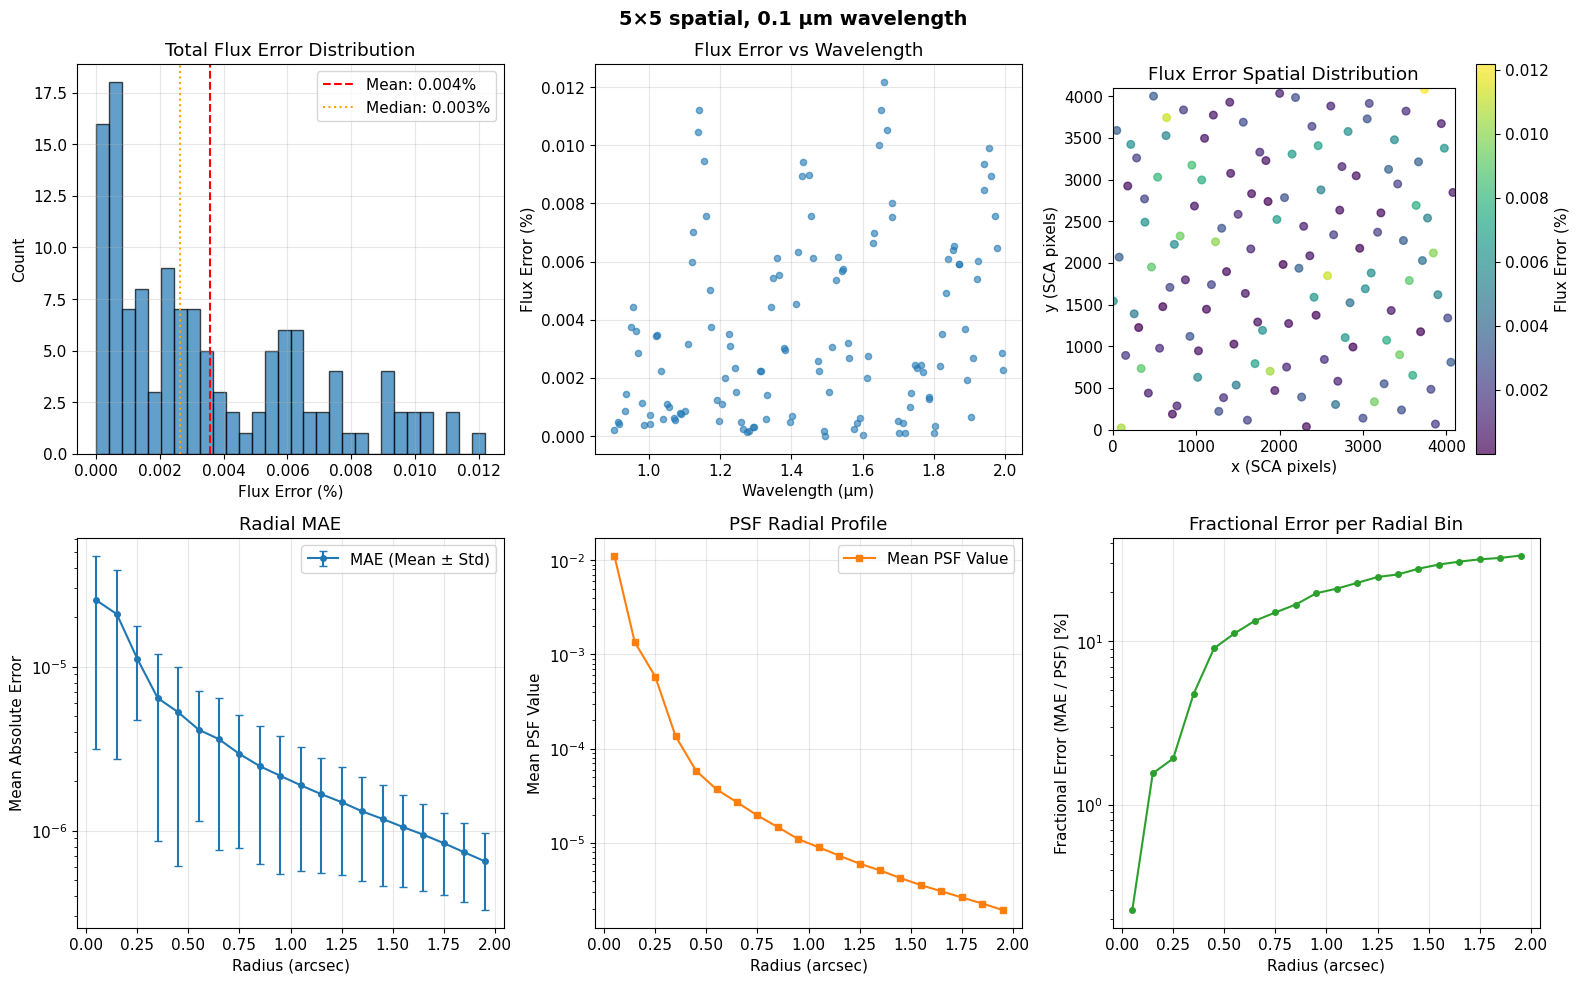

In [53]:
# Print summary and plot results for Configuration 1
print_summary_stats(results_config1, CONFIG1_NAME)
_ = plot_validation_results(results_config1, title=CONFIG1_NAME)

---

# Configuration 2: 5×5 Spatial Grid, 0.05 μm Wavelength Spacing

Finer wavelength sampling with the same spatial grid.

In [54]:
# Configuration 2: 5×5 spatial, 0.05 μm wavelength spacing
CONFIG2_NAME = "5×5 spatial, 0.05 μm wavelength"

# Wavelengths: 0.9 to 2.0 μm in 0.05 μm steps = 23 wavelengths
wavelengths_config2 = np.arange(0.9e-6, 2.01e-6, 0.05e-6)
print(f"Wavelengths: {len(wavelengths_config2)} points")
print(f"  Range: {wavelengths_config2[0]*1e6:.2f} - {wavelengths_config2[-1]*1e6:.2f} μm")

# Use same spatial grid as Config 1
spatial_grid_config2 = spatial_grid_config1
print(f"Spatial grid: {len(spatial_grid_config2['x'])}×{len(spatial_grid_config2['y'])}")

n_psfs = len(wavelengths_config2) * len(spatial_grid_config2['x']) * len(spatial_grid_config2['y'])
print(f"Total PSFs to generate: {n_psfs}")

Wavelengths: 23 points
  Range: 0.90 - 2.00 μm
Spatial grid: 5×5
Total PSFs to generate: 575


In [55]:
# Generate PSF payload for Configuration 2
print(f"Generating PSF payload: {CONFIG2_NAME}")
print()

t_start = time.time()
payload_config2 = psf_model.make_psf_payload(
    detector=DETECTOR,
    order=ORDER,
    wavelengths=wavelengths_config2,
    spatial_grid=spatial_grid_config2,
    fov_arcsec=FOV_ARCSEC,
    oversample=OVERSAMPLE,
    verbose=True
)
t_payload2 = time.time() - t_start

print(f"\nPayload generation time: {t_payload2:.1f}s ({t_payload2/60:.1f} min)")
print(f"PSF grid shape: {payload_config2['psf_grid'].shape}")
print(f"Memory: {payload_config2['psf_grid'].nbytes / 1e6:.1f} MB")

Generating PSF payload: 5×5 spatial, 0.05 μm wavelength

Generating PSF grid for WFI02, order 1...
  Spatial grid: 5×5 positions
  Wavelengths: 23 samples (0.90-2.00 μm)
  Total PSFs: 575
  FOV: 5.0 arcsec, Oversample: 4×
  This may take 30-60 minutes...


Attempted to get aberrations at wavelength 9e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at field point (4, 4) which is outside the range of the reference data; approximating to nearest interpolated point (38.88344255570929, 4.0086323787566585)
Attempted to get aberrations at wavelength 9.5e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.5e-07 

  Progress: 10/25 positions (40.0%), ETA: 2.1 min


Attempted to get aberrations at wavelength 9.5e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.5e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.5e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.5e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.5e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at field point (4, 2047) which is outside the range of the reference data; approximating to nearest interpolated point (38.37787465793884, 2047.0085072691556)
Attempted to get aberrations at field point (4, 2047) which is outside the range of the reference data; approximating to nearest interpolated point (38.37787465793884,

  Progress: 20/25 positions (80.0%), ETA: 0.7 min


Attempted to get aberrations at wavelength 9.5e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.5e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.5e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.5e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.5e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at field point (4, 4091) which is outside the range of the reference data; approximating to nearest input grid point
Attempted to get aberrations at field point (4, 4091) which is outside the range of the reference data; approximating to nearest input grid point
Attempted to get aberrations at field point (4, 4091) which is 


PSF grid generation complete:
  Total time: 207.8 seconds (3.5 minutes)
  Time per PSF: 0.36 seconds
  Total PSFs calculated: 575

PSF payload created:
  PSF grid shape: (23, 5, 5, 184, 184)
  Memory usage: 77.9 MB
  Timing: 207.8s (3.5 min)

Payload generation time: 207.8s (3.5 min)
PSF grid shape: (23, 5, 5, 184, 184)
Memory: 77.9 MB


In [56]:
# Validate Configuration 2
print(f"\nValidating: {CONFIG2_NAME}")
print()

results_config2 = validate_interpolation(
    payload_config2,
    x_test, y_test, wl_test,
    DETECTOR, ORDER,
    FOV_ARCSEC, OVERSAMPLE,
    RADIAL_BIN_SIZE, RADIAL_MAX,
    verbose=True
)


Validating: 5×5 spatial, 0.05 μm wavelength



Attempted to get aberrations at wavelength 9.4e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.4e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.4e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.4e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.4e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at field point (3943, 3674) which is outside the range of the reference data; approximating to nearest interpolated point (3942.9493592322137, 3572.0601344464817)
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wa

  [16/128] flux_err=2.74e-05, elapsed=6.1s, ETA=43.0s


Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at field point (2194, 3987) which is outside the range of the reference data; approximating to nearest interpolated point (2193.79430157175, 3572.9290639336455)
Attempted to get aberrations at field point (1208, 3777) which is outside the range of the reference data; approximating to nearest interpolated point (1207.89886678

  [32/128] flux_err=4.18e-08, elapsed=12.2s, ETA=36.6s


...

  [96/128] flux_err=8.26e-06, elapsed=36.5s, ETA=12.2s


Attempted to get aberrations at wavelength 9.7e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.7e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.7e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.7e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.7e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.8e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.8e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.8e-07 outside the range of the reference data; clipp

  [112/128] flux_err=2.14e-05, elapsed=42.4s, ETA=6.1s


Attempted to get aberrations at field point (490, 4004) which is outside the range of the reference data; approximating to nearest interpolated point (489.78627698245634, 3573.7755656845593)
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 9.2e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wav

  [128/128] flux_err=1.22e-06, elapsed=48.6s, ETA=0.0s

Validation complete:
  Total time: 48.6s (0.38s per point)
  Interpolation time: 0.574s (4.48ms per point)
  Direct STPSF time: 47.9s (0.37s per point)
  Flux error: mean=1.22e-05, max=4.16e-05



Summary: 5×5 spatial, 0.05 μm wavelength

Flux Error Statistics:
  Mean:   0.0012%
  Median: 0.0009%
  Std:    0.0011%
  Max:    0.0042%
  Min:    0.0000%

Radial MAE Statistics (across all bins):
  Mean MAE:   1.87e-06
  Max MAE:    1.19e-05
  Min MAE:    2.96e-07

Timing:
  Total validation: 48.6s
  Per test point:   0.38s
  Interpolation:    4.48ms per point
  Direct STPSF:     0.37s per point
  Speedup:          84×


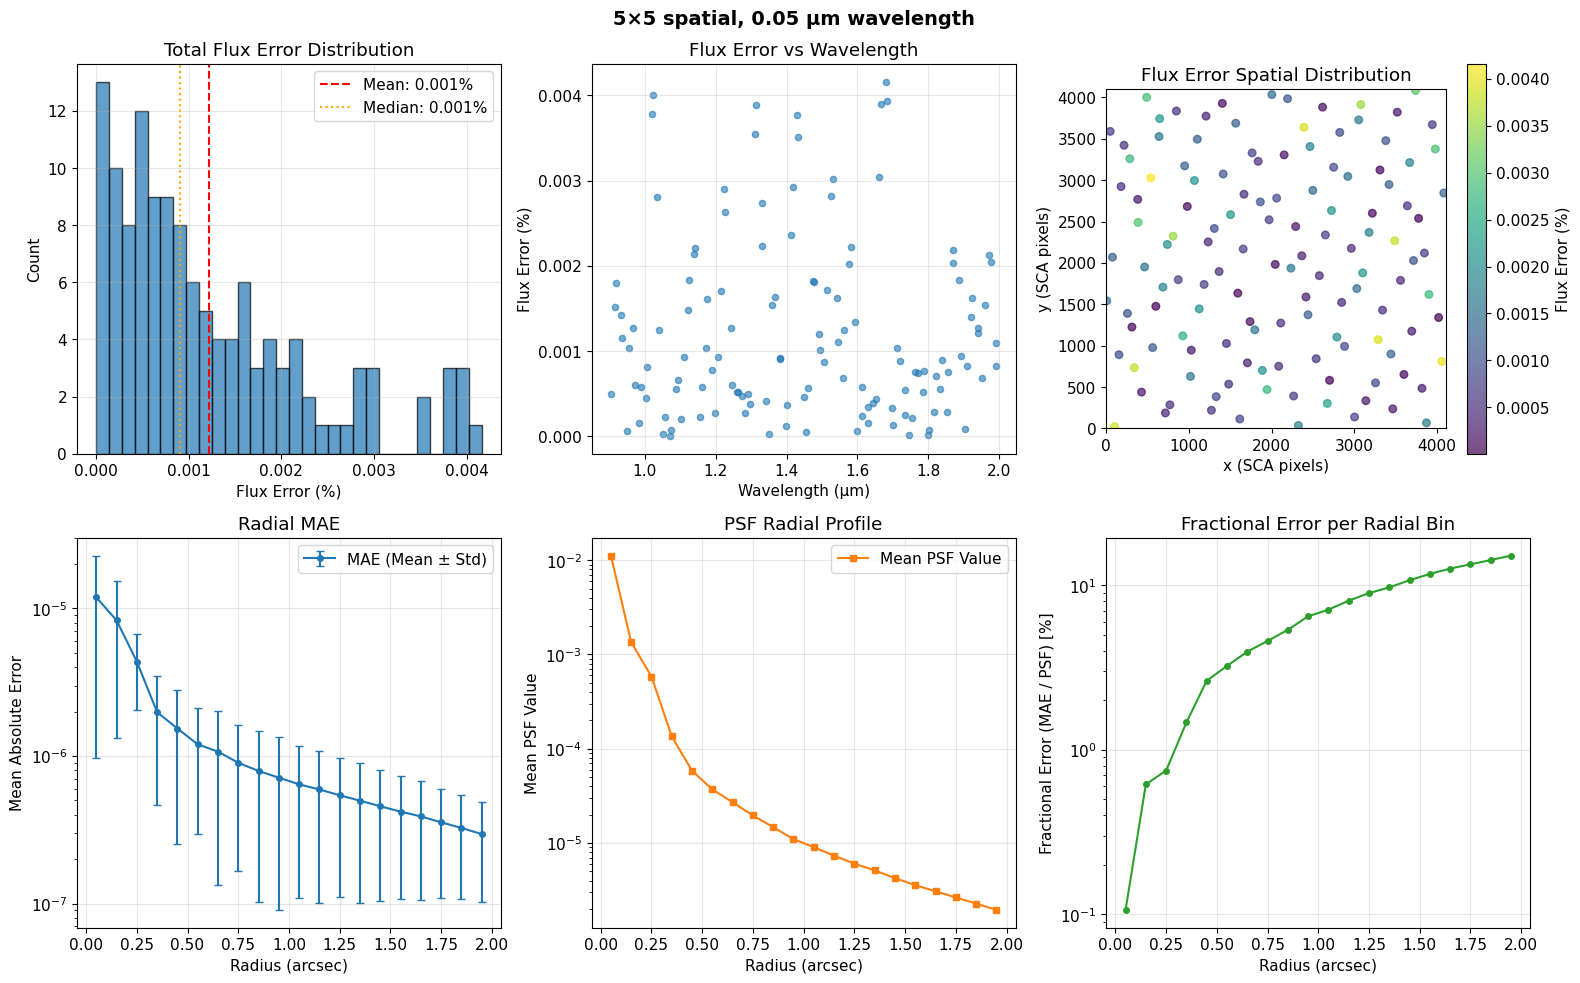

In [57]:
# Print summary and plot results for Configuration 2
print_summary_stats(results_config2, CONFIG2_NAME)
_ = plot_validation_results(results_config2, title=CONFIG2_NAME)

---

# Configuration 3: 10×10 Spatial Grid, 0.1 μm Wavelength Spacing

Finer spatial sampling with coarser wavelength grid.

In [58]:
# Configuration 3: 10×10 spatial, 0.1 μm wavelength spacing
CONFIG3_NAME = "10×10 spatial, 0.1 μm wavelength"

# Use same wavelengths as Config 1
wavelengths_config3 = wavelengths_config1
print(f"Wavelengths: {len(wavelengths_config3)} points")

# Spatial grid: 10×10
spatial_grid_config3 = {
    'x': np.linspace(1, 4088, 10),
    'y': np.linspace(1, 4088, 10)
}
print(f"Spatial grid: {len(spatial_grid_config3['x'])}×{len(spatial_grid_config3['y'])}")

n_psfs = len(wavelengths_config3) * len(spatial_grid_config3['x']) * len(spatial_grid_config3['y'])
print(f"Total PSFs to generate: {n_psfs}")

Wavelengths: 12 points
Spatial grid: 10×10
Total PSFs to generate: 1200


In [59]:
# Generate PSF payload for Configuration 3
print(f"Generating PSF payload: {CONFIG3_NAME}")
print()

t_start = time.time()
payload_config3 = psf_model.make_psf_payload(
    detector=DETECTOR,
    order=ORDER,
    wavelengths=wavelengths_config3,
    spatial_grid=spatial_grid_config3,
    fov_arcsec=FOV_ARCSEC,
    oversample=OVERSAMPLE,
    verbose=True
)
t_payload3 = time.time() - t_start

print(f"\nPayload generation time: {t_payload3:.1f}s ({t_payload3/60:.1f} min)")
print(f"PSF grid shape: {payload_config3['psf_grid'].shape}")
print(f"Memory: {payload_config3['psf_grid'].nbytes / 1e6:.1f} MB")

Generating PSF payload: 10×10 spatial, 0.1 μm wavelength

Generating PSF grid for WFI02, order 1...
  Spatial grid: 10×10 positions
  Wavelengths: 12 samples (0.90-2.00 μm)
  Total PSFs: 1200
  FOV: 5.0 arcsec, Oversample: 4×
  This may take 30-60 minutes...


Attempted to get aberrations at wavelength 9e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at field point (4, 4) which is outside the range of the reference data; approximating to nearest interpolated point (38.88344255570929, 4.0086323787566585)
Attempted to get aberrations at field point (4, 4) which is outside the range of the reference data; approximating to nearest interpolated point (38.88344255570929, 4.0086323787566

  Progress: 10/100 positions (10.0%), ETA: 6.9 min


Attempted to get aberrations at field point (4, 458) which is outside the range of the reference data; approximating to nearest interpolated point (38.77109413398252, 458.00860457662316)
Attempted to get aberrations at field point (4, 458) which is outside the range of the reference data; approximating to nearest interpolated point (38.77109413398252, 458.00860457662316)
Attempted to get aberrations at field point (4, 458) which is outside the range of the reference data; approximating to nearest interpolated point (38.77109413398252, 458.00860457662316)
Attempted to get aberrations at field point (4, 458) which is outside the range of the reference data; approximating to nearest interpolated point (38.77109413398252, 458.00860457662316)
Attempted to get aberrations at field point (4, 458) which is outside the range of the reference data; approximating to nearest interpolated point (38.77109413398252, 458.00860457662316)
Attempted to get aberrations at field point (4, 458) which is out

  Progress: 20/100 positions (20.0%), ETA: 5.9 min


...

  Progress: 80/100 positions (80.0%), ETA: 1.5 min


Attempted to get aberrations at field point (4, 3636) which is outside the range of the reference data; approximating to nearest input grid point
Attempted to get aberrations at field point (4, 3636) which is outside the range of the reference data; approximating to nearest input grid point
Attempted to get aberrations at field point (4, 3636) which is outside the range of the reference data; approximating to nearest input grid point
Attempted to get aberrations at field point (4, 3636) which is outside the range of the reference data; approximating to nearest input grid point
Attempted to get aberrations at field point (4, 3636) which is outside the range of the reference data; approximating to nearest input grid point
Attempted to get aberrations at field point (4, 3636) which is outside the range of the reference data; approximating to nearest input grid point
Attempted to get aberrations at field point (4, 3636) which is outside the range of the reference data; approximating to nea

  Progress: 90/100 positions (90.0%), ETA: 0.7 min


Attempted to get aberrations at field point (4, 4091) which is outside the range of the reference data; approximating to nearest input grid point
Attempted to get aberrations at field point (4, 4091) which is outside the range of the reference data; approximating to nearest input grid point
Attempted to get aberrations at field point (4, 4091) which is outside the range of the reference data; approximating to nearest input grid point
Attempted to get aberrations at field point (4, 4091) which is outside the range of the reference data; approximating to nearest input grid point
Attempted to get aberrations at field point (4, 4091) which is outside the range of the reference data; approximating to nearest input grid point
Attempted to get aberrations at field point (4, 4091) which is outside the range of the reference data; approximating to nearest input grid point
Attempted to get aberrations at field point (4, 4091) which is outside the range of the reference data; approximating to nea

  Progress: 100/100 positions (100.0%), ETA: 0.0 min

PSF grid generation complete:
  Total time: 435.9 seconds (7.3 minutes)
  Time per PSF: 0.36 seconds
  Total PSFs calculated: 1200

PSF payload created:
  PSF grid shape: (12, 10, 10, 184, 184)
  Memory usage: 162.5 MB
  Timing: 435.9s (7.3 min)

Payload generation time: 436.2s (7.3 min)
PSF grid shape: (12, 10, 10, 184, 184)
Memory: 162.5 MB


In [60]:
# Validate Configuration 3
print(f"\nValidating: {CONFIG3_NAME}")
print()

results_config3 = validate_interpolation(
    payload_config3,
    x_test, y_test, wl_test,
    DETECTOR, ORDER,
    FOV_ARCSEC, OVERSAMPLE,
    RADIAL_BIN_SIZE, RADIAL_MAX,
    verbose=True
)


Validating: 10×10 spatial, 0.1 μm wavelength



Attempted to get aberrations at wavelength 9.4e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.4e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.4e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.4e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.4e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at field point (3943, 3674) which is outside the range of the reference data; approximating to nearest interpolated point (3942.9493592322137, 3572.0601344464817)
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wa

  [16/128] flux_err=5.99e-06, elapsed=6.0s, ETA=42.0s


Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at field point (2194, 3987) which is outside the range of the reference data; approximating to nearest interpolated point (2193.79430157175, 3572.9290639336455)
Attempted to get aberrations at field point (1208, 3777) which is outside the range of the reference data; approximating to nearest interpolated point (1207.89886678

  [32/128] flux_err=7.41e-06, elapsed=11.8s, ETA=35.4s


...

  [96/128] flux_err=2.26e-05, elapsed=35.7s, ETA=11.9s


Attempted to get aberrations at wavelength 9.7e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.7e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.7e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.7e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.7e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.8e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.8e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.8e-07 outside the range of the reference data; clipp

  [112/128] flux_err=1.05e-04, elapsed=41.8s, ETA=6.0s


Attempted to get aberrations at field point (490, 4004) which is outside the range of the reference data; approximating to nearest interpolated point (489.78627698245634, 3573.7755656845593)
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 9.2e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wav

  [128/128] flux_err=4.78e-06, elapsed=47.7s, ETA=0.0s

Validation complete:
  Total time: 47.7s (0.37s per point)
  Interpolation time: 0.521s (4.07ms per point)
  Direct STPSF time: 47.1s (0.37s per point)
  Flux error: mean=3.56e-05, max=1.22e-04



Summary: 10×10 spatial, 0.1 μm wavelength

Flux Error Statistics:
  Mean:   0.0036%
  Median: 0.0026%
  Std:    0.0031%
  Max:    0.0122%
  Min:    0.0000%

Radial MAE Statistics (across all bins):
  Mean MAE:   4.58e-06
  Max MAE:    2.30e-05
  Min MAE:    6.51e-07

Timing:
  Total validation: 47.7s
  Per test point:   0.37s
  Interpolation:    4.07ms per point
  Direct STPSF:     0.37s per point
  Speedup:          90×


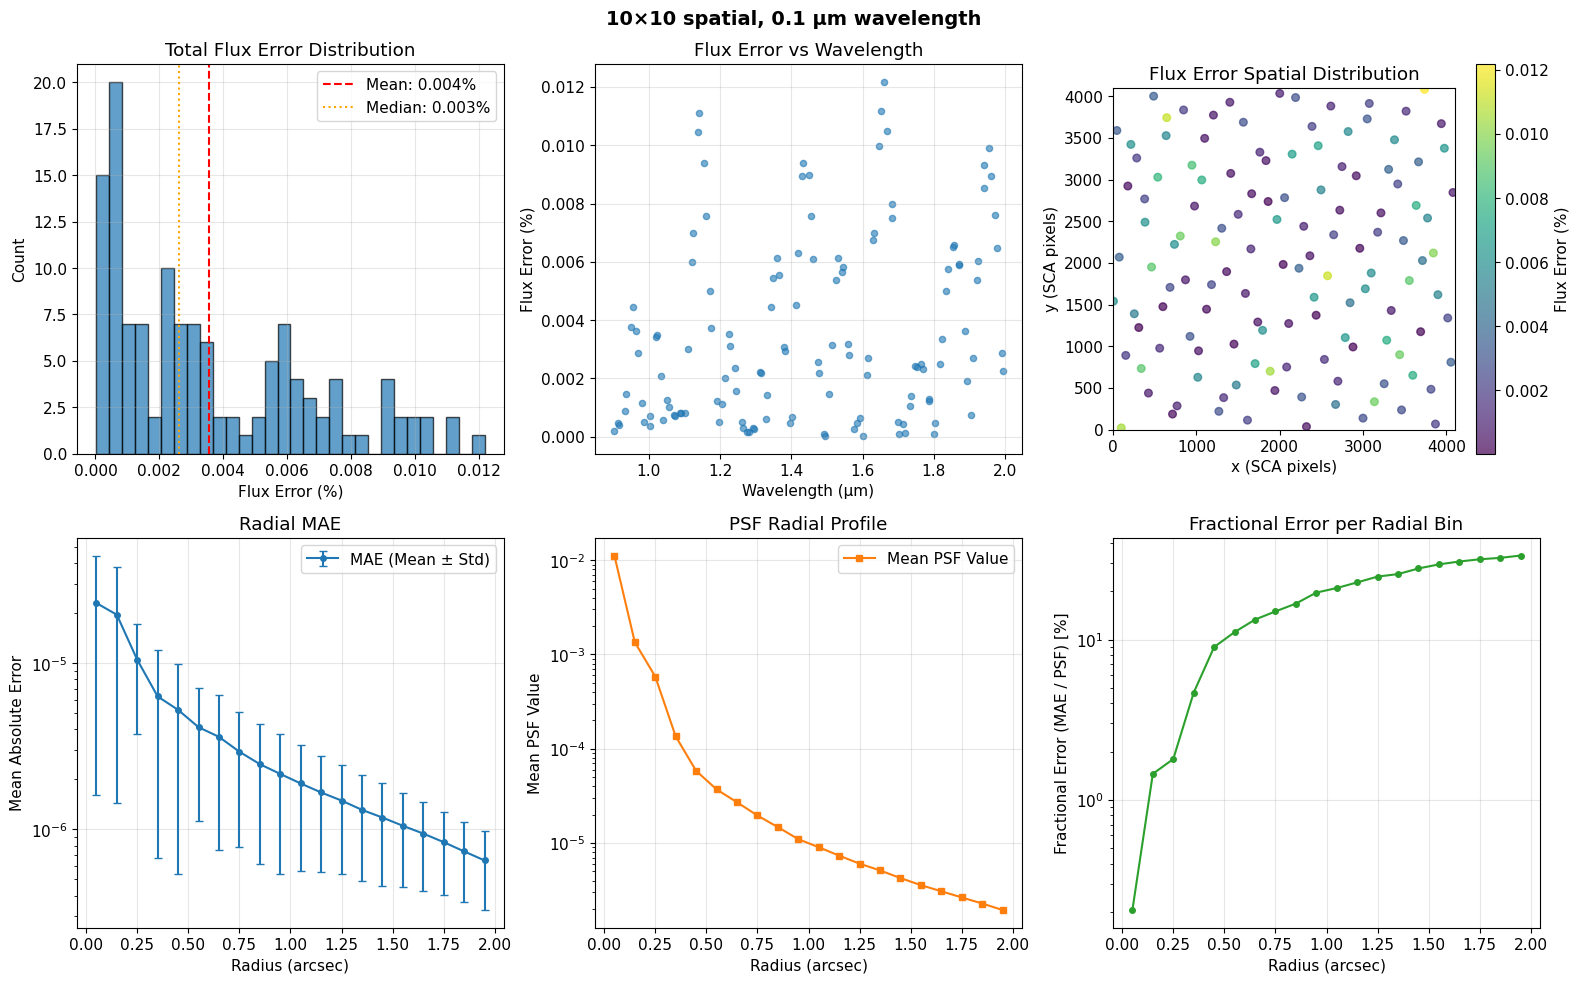

In [61]:
# Print summary and plot results for Configuration 3
print_summary_stats(results_config3, CONFIG3_NAME)
_ = plot_validation_results(results_config3, title=CONFIG3_NAME)

---

# Configuration 4: 3×3 Spatial Grid, 0.02 μm Wavelength Spacing

Testing hypothesis: finer wavelength sampling reduces radial errors in PSF wings,
while coarser spatial grid is sufficient (since 5×5 ≈ 10×10 in accuracy).

In [62]:
# Configuration 4: 3×3 spatial, 0.02 μm wavelength spacing
CONFIG4_NAME = "3×3 spatial, 0.02 μm wavelength"

# Wavelengths: 0.9 to 2.0 μm in 0.02 μm steps
wavelengths_config4 = np.arange(0.9e-6, 2.01e-6, 0.02e-6)
print(f"Wavelengths: {len(wavelengths_config4)} points")
print(f"  Range: {wavelengths_config4[0]*1e6:.2f} - {wavelengths_config4[-1]*1e6:.2f} μm")

# Spatial grid: 3×3
spatial_grid_config4 = {
    'x': np.linspace(1, 4088, 3),
    'y': np.linspace(1, 4088, 3)
}
print(f"Spatial grid: {len(spatial_grid_config4['x'])}×{len(spatial_grid_config4['y'])}")

n_psfs = len(wavelengths_config4) * len(spatial_grid_config4['x']) * len(spatial_grid_config4['y'])
print(f"Total PSFs to generate: {n_psfs}")

Wavelengths: 56 points
  Range: 0.90 - 2.00 μm
Spatial grid: 3×3
Total PSFs to generate: 504


In [63]:
# Generate PSF payload for Configuration 4
print(f"Generating PSF payload: {CONFIG4_NAME}")
print()

t_start = time.time()
payload_config4 = psf_model.make_psf_payload(
    detector=DETECTOR,
    order=ORDER,
    wavelengths=wavelengths_config4,
    spatial_grid=spatial_grid_config4,
    fov_arcsec=FOV_ARCSEC,
    oversample=OVERSAMPLE,
    verbose=True
)
t_payload4 = time.time() - t_start

print(f"\nPayload generation time: {t_payload4:.1f}s ({t_payload4/60:.1f} min)")
print(f"PSF grid shape: {payload_config4['psf_grid'].shape}")
print(f"Memory: {payload_config4['psf_grid'].nbytes / 1e6:.1f} MB")

Generating PSF payload: 3×3 spatial, 0.02 μm wavelength

Generating PSF grid for WFI02, order 1...
  Spatial grid: 3×3 positions
  Wavelengths: 56 samples (0.90-2.00 μm)
  Total PSFs: 504
  FOV: 5.0 arcsec, Oversample: 4×
  This may take 30-60 minutes...


Attempted to get aberrations at wavelength 9e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at field point (4, 4) which is outside the range of the reference data; approximating to nearest interpolated point (38.88344255570929, 4.0086323787566585)
Attempted to get aberrations at wavelength 9.2e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.2e-07 


PSF grid generation complete:
  Total time: 187.5 seconds (3.1 minutes)
  Time per PSF: 0.37 seconds
  Total PSFs calculated: 504

PSF payload created:
  PSF grid shape: (56, 3, 3, 184, 184)
  Memory usage: 68.3 MB
  Timing: 187.5s (3.1 min)

Payload generation time: 187.7s (3.1 min)
PSF grid shape: (56, 3, 3, 184, 184)
Memory: 68.3 MB


In [64]:
# Validate Configuration 4
print(f"\nValidating: {CONFIG4_NAME}")
print()

results_config4 = validate_interpolation(
    payload_config4,
    x_test, y_test, wl_test,
    DETECTOR, ORDER,
    FOV_ARCSEC, OVERSAMPLE,
    RADIAL_BIN_SIZE, RADIAL_MAX,
    verbose=True
)


Validating: 3×3 spatial, 0.02 μm wavelength



Attempted to get aberrations at wavelength 9.4e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.4e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.4e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.4e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.4e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at field point (3943, 3674) which is outside the range of the reference data; approximating to nearest interpolated point (3942.9493592322137, 3572.0601344464817)
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wa

  [16/128] flux_err=3.21e-06, elapsed=6.2s, ETA=43.2s


Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at field point (2194, 3987) which is outside the range of the reference data; approximating to nearest interpolated point (2193.79430157175, 3572.9290639336455)
Attempted to get aberrations at field point (1208, 3777) which is outside the range of the reference data; approximating to nearest interpolated point (1207.89886678

  [32/128] flux_err=4.50e-06, elapsed=12.1s, ETA=36.4s


...

  [96/128] flux_err=1.41e-06, elapsed=36.7s, ETA=12.2s


Attempted to get aberrations at wavelength 9.7e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.7e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.7e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.7e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.7e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.8e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.8e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.8e-07 outside the range of the reference data; clipp

  [112/128] flux_err=3.32e-06, elapsed=42.9s, ETA=6.1s


Attempted to get aberrations at field point (490, 4004) which is outside the range of the reference data; approximating to nearest interpolated point (489.78627698245634, 3573.7755656845593)
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 9.2e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wav

  [128/128] flux_err=9.86e-07, elapsed=49.1s, ETA=0.0s

Validation complete:
  Total time: 49.1s (0.38s per point)
  Interpolation time: 0.743s (5.80ms per point)
  Direct STPSF time: 48.3s (0.38s per point)
  Flux error: mean=2.88e-06, max=1.30e-05



Summary: 3×3 spatial, 0.02 μm wavelength

Flux Error Statistics:
  Mean:   0.0003%
  Median: 0.0002%
  Std:    0.0002%
  Max:    0.0013%
  Min:    0.0000%

Radial MAE Statistics (across all bins):
  Mean MAE:   2.56e-06
  Max MAE:    2.35e-05
  Min MAE:    6.95e-08

Timing:
  Total validation: 49.1s
  Per test point:   0.38s
  Interpolation:    5.80ms per point
  Direct STPSF:     0.38s per point
  Speedup:          65×


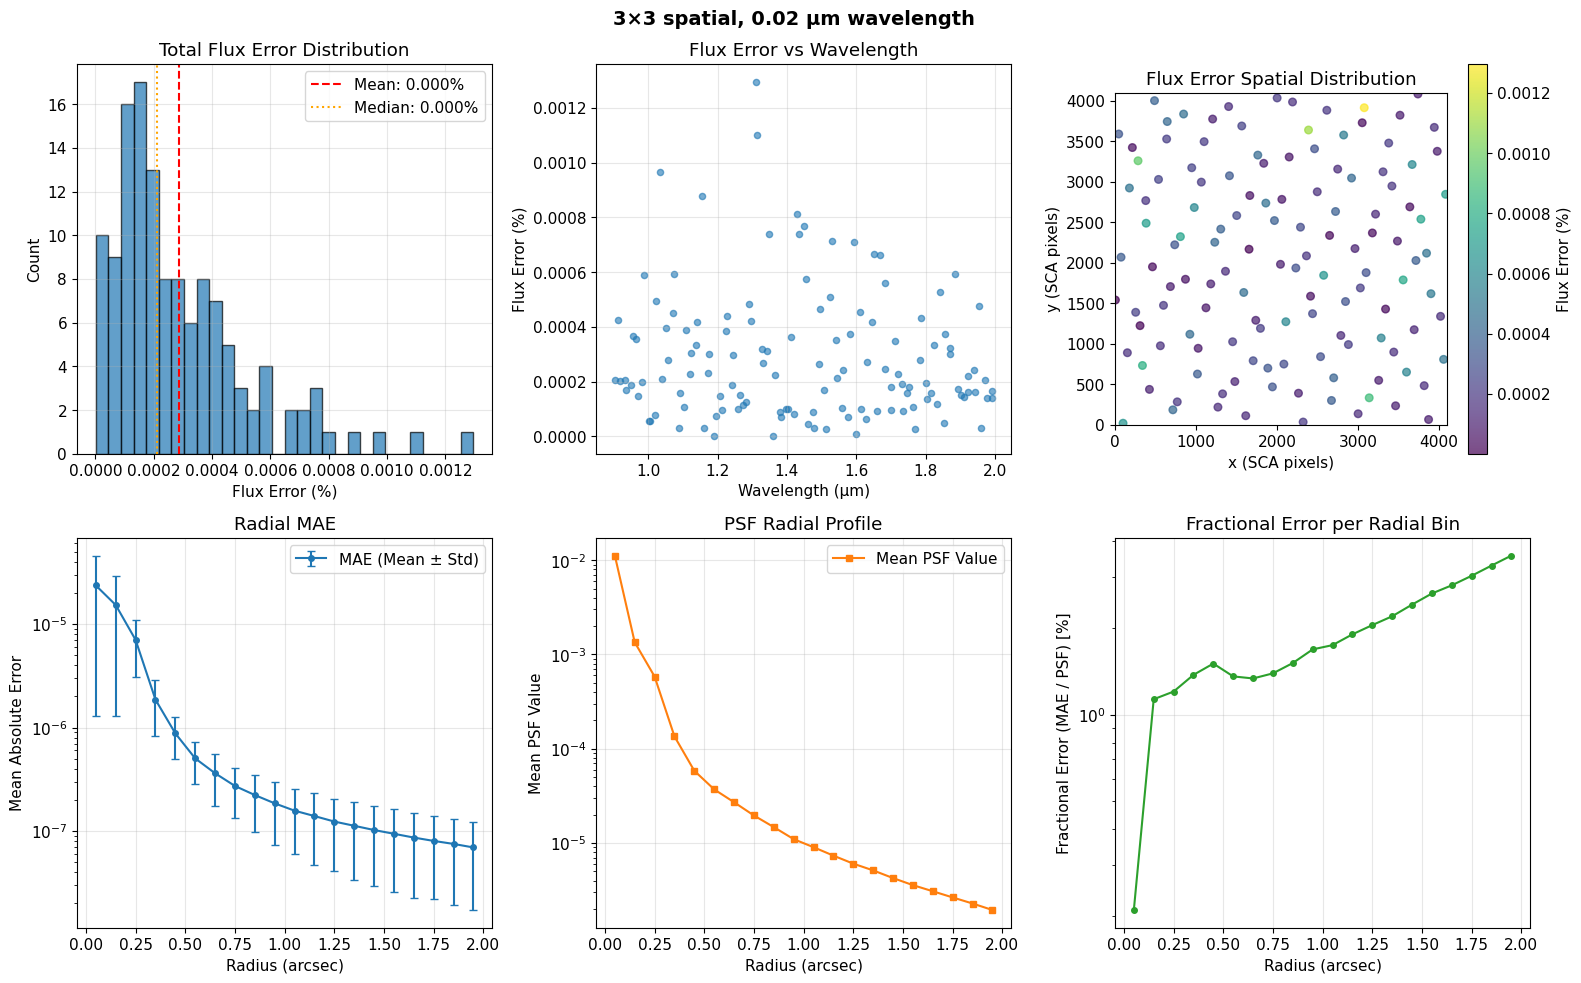

In [65]:
# Print summary and plot results for Configuration 4
print_summary_stats(results_config4, CONFIG4_NAME)
_ = plot_validation_results(results_config4, title=CONFIG4_NAME)

---

# Configuration 5: 4×4 Spatial Grid, 0.02 μm Wavelength Spacing

Testing: finer wavelength (0.02 μm) for wing accuracy + adequate spatial (4×4) for core accuracy.
This should combine the best of CONFIG4's wing accuracy with CONFIG1-3's core accuracy.

In [77]:
# Configuration 5: 4×4 spatial, 0.02 μm wavelength spacing
CONFIG5_NAME = "4×4 spatial, 0.02 μm wavelength"

# Wavelengths: same as CONFIG4 (0.02 μm steps)
wavelengths_config5 = wavelengths_config4
print(f"Wavelengths: {len(wavelengths_config5)} points")
print(f"  Range: {wavelengths_config5[0]*1e6:.2f} - {wavelengths_config5[-1]*1e6:.2f} μm")

# Spatial grid: 4×4
spatial_grid_config5 = {
    'x': np.linspace(1, 4088, 4),
    'y': np.linspace(1, 4088, 4)
}
print(f"Spatial grid: {len(spatial_grid_config5['x'])}×{len(spatial_grid_config5['y'])}")

n_psfs = len(wavelengths_config5) * len(spatial_grid_config5['x']) * len(spatial_grid_config5['y'])
print(f"Total PSFs to generate: {n_psfs}")

Wavelengths: 56 points
  Range: 0.90 - 2.00 μm
Spatial grid: 4×4
Total PSFs to generate: 896


In [78]:
# Generate PSF payload for Configuration 5
print(f"Generating PSF payload: {CONFIG5_NAME}")
print()

t_start = time.time()
payload_config5 = psf_model.make_psf_payload(
    detector=DETECTOR,
    order=ORDER,
    wavelengths=wavelengths_config5,
    spatial_grid=spatial_grid_config5,
    fov_arcsec=FOV_ARCSEC,
    oversample=OVERSAMPLE,
    verbose=True
)
t_payload5 = time.time() - t_start

print(f"\nPayload generation time: {t_payload5:.1f}s ({t_payload5/60:.1f} min)")
print(f"PSF grid shape: {payload_config5['psf_grid'].shape}")
print(f"Memory: {payload_config5['psf_grid'].nbytes / 1e6:.1f} MB")

Generating PSF payload: 4×4 spatial, 0.02 μm wavelength

Generating PSF grid for WFI02, order 1...
  Spatial grid: 4×4 positions
  Wavelengths: 56 samples (0.90-2.00 μm)
  Total PSFs: 896
  FOV: 5.0 arcsec, Oversample: 4×
  This may take 30-60 minutes...


Attempted to get aberrations at wavelength 9e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at field point (4, 4) which is outside the range of the reference data; approximating to nearest interpolated point (38.88344255570929, 4.0086323787566585)
Attempted to get aberrations at wavelength 9.2e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.2e-07 

  Progress: 10/16 positions (62.5%), ETA: 2.1 min


Attempted to get aberrations at wavelength 9.2e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.2e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.2e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.2e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.2e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.4e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.4e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.4e-07 outside the range of the reference data; clipp


PSF grid generation complete:
  Total time: 332.6 seconds (5.5 minutes)
  Time per PSF: 0.37 seconds
  Total PSFs calculated: 896

PSF payload created:
  PSF grid shape: (56, 4, 4, 184, 184)
  Memory usage: 121.3 MB
  Timing: 332.6s (5.5 min)

Payload generation time: 332.8s (5.5 min)
PSF grid shape: (56, 4, 4, 184, 184)
Memory: 121.3 MB


In [79]:
# Validate Configuration 5
print(f"\nValidating: {CONFIG5_NAME}")
print()

results_config5 = validate_interpolation(
    payload_config5,
    x_test, y_test, wl_test,
    DETECTOR, ORDER,
    FOV_ARCSEC, OVERSAMPLE,
    RADIAL_BIN_SIZE, RADIAL_MAX,
    verbose=True
)


Validating: 4×4 spatial, 0.02 μm wavelength



Attempted to get aberrations at wavelength 9.4e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.4e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.4e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.4e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.4e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at field point (3943, 3674) which is outside the range of the reference data; approximating to nearest interpolated point (3942.9493592322137, 3572.0601344464817)
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wa

  [16/128] flux_err=3.02e-06, elapsed=6.3s, ETA=44.0s


Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at field point (2194, 3987) which is outside the range of the reference data; approximating to nearest interpolated point (2193.79430157175, 3572.9290639336455)
Attempted to get aberrations at field point (1208, 3777) which is outside the range of the reference data; approximating to nearest interpolated point (1207.89886678

  [32/128] flux_err=3.40e-06, elapsed=12.2s, ETA=36.6s


...

  [96/128] flux_err=1.35e-06, elapsed=35.6s, ETA=11.9s


Attempted to get aberrations at wavelength 9.7e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.7e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.7e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.7e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.7e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.8e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.8e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.8e-07 outside the range of the reference data; clipp

  [112/128] flux_err=2.71e-06, elapsed=41.4s, ETA=5.9s


Attempted to get aberrations at field point (490, 4004) which is outside the range of the reference data; approximating to nearest interpolated point (489.78627698245634, 3573.7755656845593)
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 2e-06 outside the range of the reference data; clipping to closest wavelength 1.9e-06
Attempted to get aberrations at wavelength 9.2e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wav

  [128/128] flux_err=4.95e-07, elapsed=47.2s, ETA=0.0s

Validation complete:
  Total time: 47.2s (0.37s per point)
  Interpolation time: 0.708s (5.53ms per point)
  Direct STPSF time: 46.3s (0.36s per point)
  Flux error: mean=2.61e-06, max=1.28e-05



Summary: 4×4 spatial, 0.02 μm wavelength

Flux Error Statistics:
  Mean:   0.0003%
  Median: 0.0002%
  Std:    0.0002%
  Max:    0.0013%
  Min:    0.0000%

Radial MAE Statistics (across all bins):
  Mean MAE:   1.58e-06
  Max MAE:    1.44e-05
  Min MAE:    6.66e-08

Timing:
  Total validation: 47.2s
  Per test point:   0.37s
  Interpolation:    5.53ms per point
  Direct STPSF:     0.36s per point
  Speedup:          65×


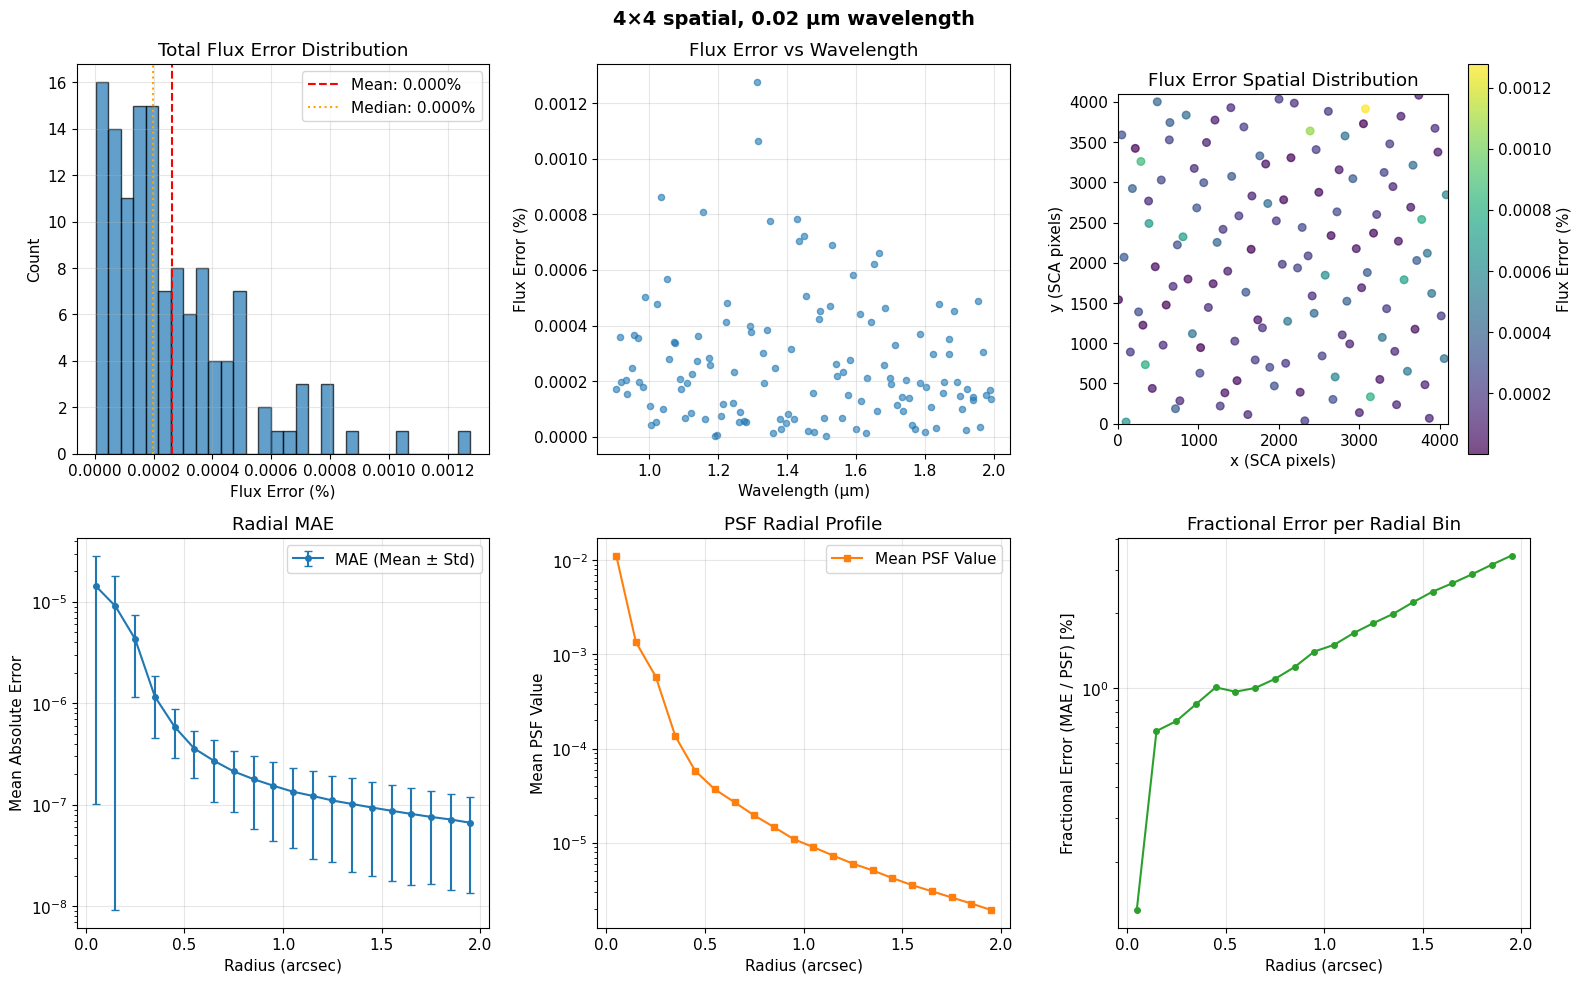

In [80]:
# Print summary and plot results for Configuration 5
print_summary_stats(results_config5, CONFIG5_NAME)
_ = plot_validation_results(results_config5, title=CONFIG5_NAME)

---

# Comparison Across Configurations

In [81]:
# Collect all results for comparison
all_configs = [
    (CONFIG1_NAME, results_config1, payload_config1, t_payload1),
    (CONFIG2_NAME, results_config2, payload_config2, t_payload2),
    (CONFIG3_NAME, results_config3, payload_config3, t_payload3),
    (CONFIG4_NAME, results_config4, payload_config4, t_payload4),
    (CONFIG5_NAME, results_config5, payload_config5, t_payload5),
]

# Create comparison table
comparison_data = []
for name, results, payload, t_gen in all_configs:
    flux_errors = results['flux_errors']
    comparison_data.append({
        'Configuration': name,
        'Grid Shape': str(payload['psf_grid'].shape[:3]),
        'Memory (MB)': f"{payload['psf_grid'].nbytes / 1e6:.1f}",
        'Gen Time (min)': f"{t_gen / 60:.1f}",
        'Mean Flux Err (%)': f"{np.mean(flux_errors)*100:.4f}",
        'Max Flux Err (%)': f"{np.max(flux_errors)*100:.4f}",
        'Median Flux Err (%)': f"{np.median(flux_errors)*100:.4f}",
        'Interp Speed (ms)': f"{results['timing']['interp_per_point']*1000:.2f}",
    })

comparison_df = pd.DataFrame(comparison_data)
print("\nConfiguration Comparison")
print("="*100)
comparison_df


Configuration Comparison


,Configuration,Grid Shape,Memory (MB),Gen Time (min),Mean Flux Err (%),Max Flux Err (%),Median Flux Err (%),Interp Speed (ms)
0,"5×5 spatial, 0.1 μm wavelength","(12, 5, 5)",40.6,1.8,0.0036,0.0122,0.0026,3.70
1,"5×5 spatial, 0.05 μm wavelength","(23, 5, 5)",77.9,3.5,0.0012,0.0042,0.0009,4.48
2,"10×10 spatial, 0.1 μm wavelength","(12, 10, 10)",162.5,7.3,0.0036,0.0122,0.0026,4.07
3,"3×3 spatial, 0.02 μm wavelength","(56, 3, 3)",68.3,3.1,0.0003,0.0013,0.0002,5.80
4,"4×4 spatial, 0.02 μm wavelength","(56, 4, 4)",121.3,5.5,0.0003,0.0013,0.0002,5.53


/var/folders/5s/z32x1yyd4wd7q51zc60yx_0c0000gn/T/ipykernel_63059/3867054349.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(flux_data, labels=labels, patch_artist=True)


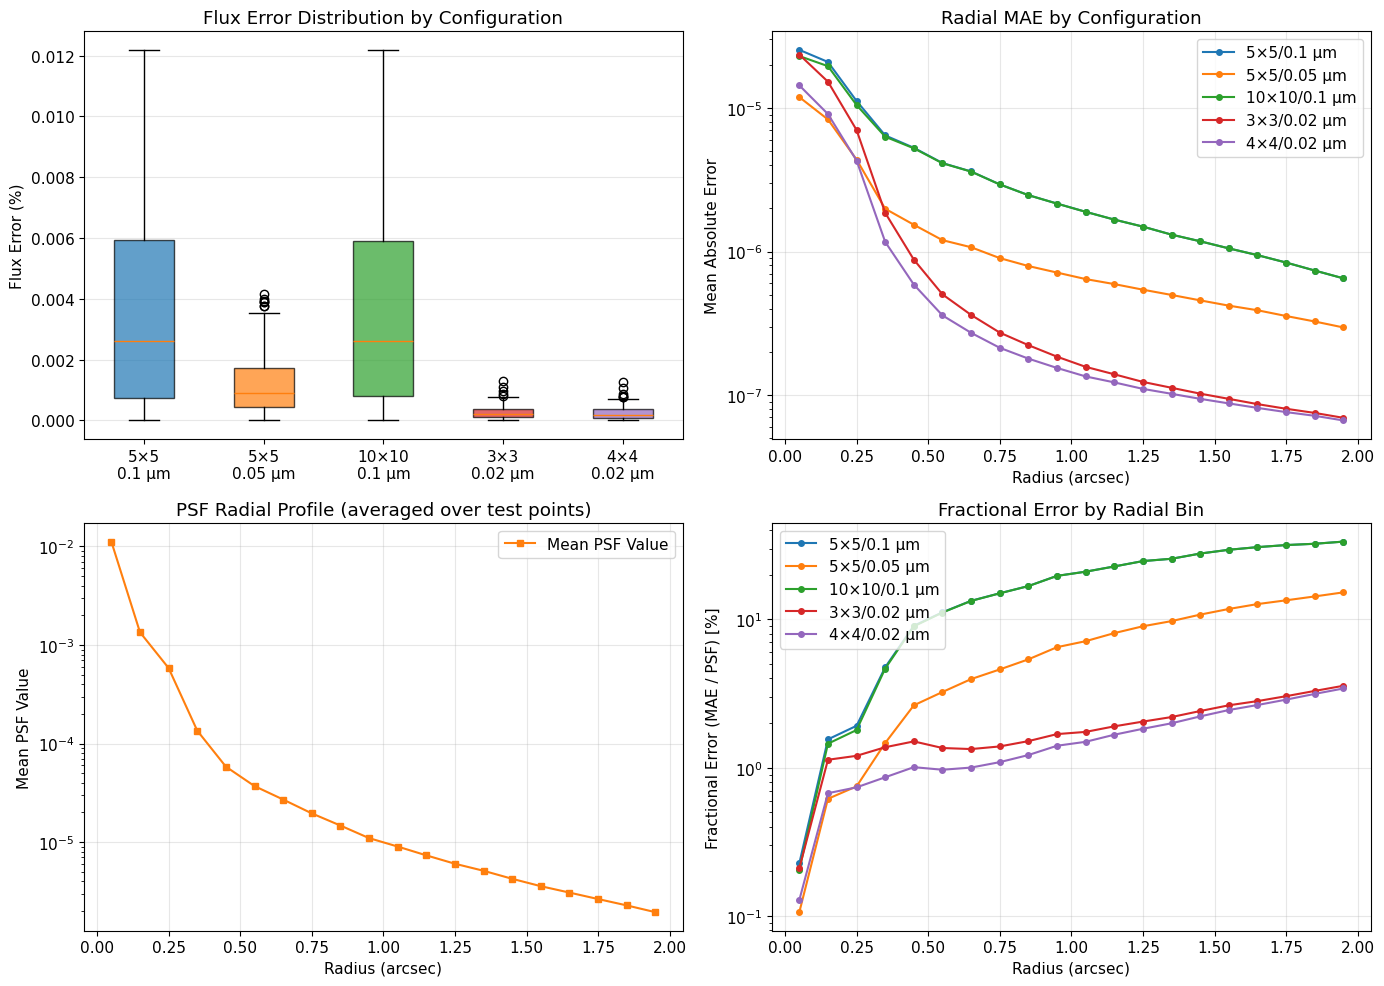

In [82]:
# Visual comparison: Flux error distributions and radial profiles
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

n_configs = len(all_configs)
colors = plt.cm.tab10.colors[:n_configs]

# 1. Box plot of flux errors
ax = axes[0, 0]
flux_data = [r[1]['flux_errors'] * 100 for r in all_configs]
labels = [r[0].replace(' spatial, ', '\n').replace(' wavelength', '') for r in all_configs]
bp = ax.boxplot(flux_data, labels=labels, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('Flux Error (%)')
ax.set_title('Flux Error Distribution by Configuration')
ax.grid(alpha=0.3, axis='y')

# 2. Radial MAE comparison
ax = axes[0, 1]
for (name, results, _, _), color in zip(all_configs, colors):
    bin_edges = results['bin_edges']
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    mean_mae = results['mean_mae_per_bin']
    short_name = name.replace(' spatial, ', '/').replace(' wavelength', '')
    ax.plot(bin_centers, mean_mae, 'o-', color=color, label=short_name, markersize=4)

ax.set_xlabel('Radius (arcsec)')
ax.set_ylabel('Mean Absolute Error')
ax.set_title('Radial MAE by Configuration')
ax.set_yscale('log')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)

# 3. PSF profile (same for all configs, just show one)
ax = axes[1, 0]
name, results, _, _ = all_configs[0]  # Use 5x5/0.1um config
bin_edges = results['bin_edges']
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
mean_psf = results['mean_psf_per_bin']

ax.plot(bin_centers, mean_psf, 's-', color='tab:orange', markersize=4, label='Mean PSF Value')
ax.set_xlabel('Radius (arcsec)')
ax.set_ylabel('Mean PSF Value')
ax.set_title('PSF Radial Profile (averaged over test points)')
ax.set_yscale('log')
ax.grid(alpha=0.3)
ax.legend()

# 4. MAE / PSF ratio (fractional error per bin)
ax = axes[1, 1]
for (name, results, _, _), color in zip(all_configs, colors):
    bin_edges = results['bin_edges']
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    mean_mae = results['mean_mae_per_bin']
    mean_psf = results['mean_psf_per_bin']
    # Fractional error: MAE / PSF (where PSF > threshold)
    threshold = 1e-8
    frac_error = np.where(mean_psf > threshold, mean_mae / mean_psf, np.nan)
    short_name = name.replace(' spatial, ', '/').replace(' wavelength', '')
    ax.plot(bin_centers, frac_error * 100, 'o-', color=color, label=short_name, markersize=4)

ax.set_xlabel('Radius (arcsec)')
ax.set_ylabel('Fractional Error (MAE / PSF) [%]')
ax.set_title('Fractional Error by Radial Bin')
ax.set_yscale('log')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

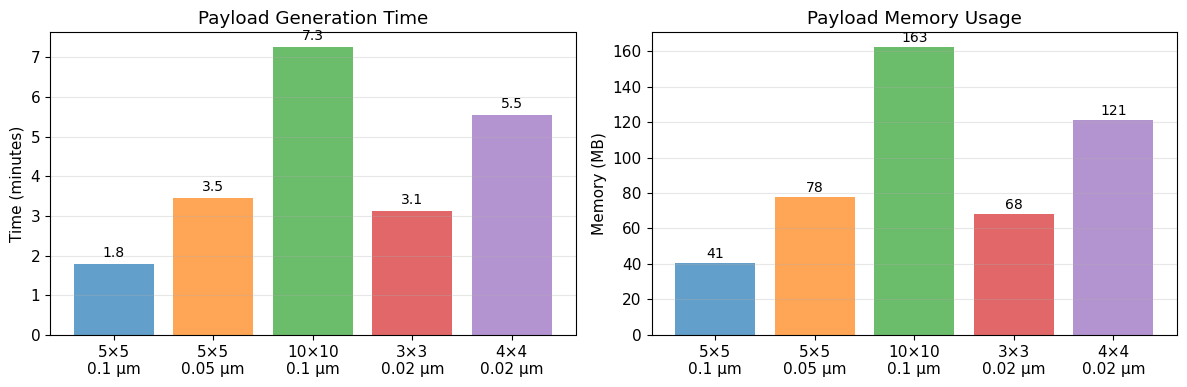

In [83]:
# Timing comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

n_configs = len(all_configs)
colors = plt.cm.tab10.colors[:n_configs]
configs_short = [name.replace(' spatial, ', '\n').replace(' wavelength', '') 
                 for name, _, _, _ in all_configs]

# Payload generation time
ax = axes[0]
gen_times = [t / 60 for _, _, _, t in all_configs]
bars = ax.bar(configs_short, gen_times, color=colors, alpha=0.7)
ax.set_ylabel('Time (minutes)')
ax.set_title('Payload Generation Time')
ax.grid(alpha=0.3, axis='y')
for bar, t in zip(bars, gen_times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
            f'{t:.1f}', ha='center', va='bottom', fontsize=10)

# Memory usage
ax = axes[1]
mem_mb = [p['psf_grid'].nbytes / 1e6 for _, _, p, _ in all_configs]
bars = ax.bar(configs_short, mem_mb, color=colors, alpha=0.7)
ax.set_ylabel('Memory (MB)')
ax.set_title('Payload Memory Usage')
ax.grid(alpha=0.3, axis='y')
for bar, m in zip(bars, mem_mb):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{m:.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

---

# Detailed PSF Comparison Examples

Visual comparison of interpolated vs direct PSFs at a few test points.

In [89]:
def plot_psf_comparison(payload, x, y, wl, detector, order, fov_arcsec, oversample, title=''):
    """
    Plot side-by-side comparison of interpolated vs direct PSF.
    
    Parameters
    ----------
    payload : dict
        PSF payload
    x, y : float
        SCA coordinates
    wl : float
        Wavelength in meters
    detector : str
        Detector name
    order : str
        Spectral order
    fov_arcsec : float
        Field of view
    oversample : int
        Oversampling factor
    title : str
        Plot title prefix
    """
    # Get interpolated PSF
    psf_interp = np.asarray(psf_model.interpolate_psf(payload, float(x), float(y), float(wl)))
    
    # Get direct PSF
    filter_map = {'0': 'GRISM0', '1': 'GRISM1'}
    wfi = stpsf.roman.WFI()
    wfi.filter = filter_map[order]
    wfi.detector = detector
    psf_direct = compute_direct_psf(wfi, x, y, wl, fov_arcsec, oversample)
    
    # Compute residual
    residual = psf_interp - psf_direct
    
    # Stats
    flux_interp = psf_interp.sum()
    flux_direct = psf_direct.sum()
    flux_error = abs(flux_interp - flux_direct) / flux_direct
    
    # Plot
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    vmax = max(psf_interp.max(), psf_direct.max())
    vmin = vmax * 1e-5
    
    # Interpolated
    ax = axes[0]
    im = ax.imshow(psf_interp, origin='lower', cmap='inferno', 
                   norm=LogNorm(vmin=vmin, vmax=vmax))
    ax.set_title(f'Interpolated (flux={flux_interp:.4f})')
    ax.tick_params(labelbottom=False, labelleft=False)
    plt.colorbar(im, ax=ax, shrink=0.8)
    
    # Direct
    ax = axes[1]
    im = ax.imshow(psf_direct, origin='lower', cmap='inferno', 
                   norm=LogNorm(vmin=vmin, vmax=vmax))
    ax.set_title(f'Direct STPSF (flux={flux_direct:.4f})')
    ax.tick_params(labelbottom=False, labelleft=False)
    plt.colorbar(im, ax=ax, shrink=0.8)
    
    # Residual (linear scale)
    ax = axes[2]
    res_max = max(abs(residual.min()), abs(residual.max()))
    im = ax.imshow(residual, origin='lower', cmap='RdBu_r', 
                   vmin=-res_max, vmax=res_max)
    ax.set_title(f'Residual (Interp - Direct)')
    ax.tick_params(labelbottom=False, labelleft=False)
    plt.colorbar(im, ax=ax, shrink=0.8)
    
    # Fractional residual
    ax = axes[3]
    # Avoid division by zero using a threshold
    threshold = vmax * 1e-4
    frac_residual = residual / np.maximum(psf_direct, threshold)
    frac_max = 0.1  # Cap at 10%
    im = ax.imshow(frac_residual * 100, origin='lower', cmap='RdBu_r', 
                   vmin=-frac_max*100, vmax=frac_max*100)
    ax.set_title(f'Fractional Residual (%)')
    ax.tick_params(labelbottom=False, labelleft=False)
    plt.colorbar(im, ax=ax, shrink=0.8)
    
    fig.suptitle(f'{title}\nx={x:.0f}, y={y:.0f}, λ={wl*1e6:.3f}μm | Flux Error: {flux_error*100:.3f}%',
                 fontsize=12)
    plt.tight_layout()
    plt.show()


print("PSF comparison function defined.")

PSF comparison function defined.


In [90]:
# Select a few test points to visualize
# Use indices that span different flux error levels
# Using Config 5 (4×4/0.02μm) as it's the recommended configuration
flux_errors = results_config5['flux_errors']
sorted_indices = np.argsort(flux_errors)

# Pick: minimum, median, maximum error cases
example_indices = [
    sorted_indices[0],       # Minimum error
    sorted_indices[len(sorted_indices)//2],  # Median error
    sorted_indices[-1],      # Maximum error
]

print(f"Example test points (using {CONFIG5_NAME}):")
for idx in example_indices:
    print(f"  Index {idx}: x={x_test[idx]:.0f}, y={y_test[idx]:.0f}, "
          f"λ={wl_test[idx]*1e6:.3f}μm, flux_err={flux_errors[idx]*100:.4f}%")

Example test points (using 4×4 spatial, 0.02 μm wavelength):
  Index 58: x=3051, y=3729, λ=1.513μm, flux_err=0.0000%
  Index 125: x=2322, y=35, λ=0.918μm, flux_err=0.0002%
  Index 46: x=3076, y=3914, λ=1.312μm, flux_err=0.0013%


Attempted to get aberrations at field point (3053, 3731) which is outside the range of the reference data; approximating to nearest interpolated point (3052.9212629282583, 3572.5022745837414)


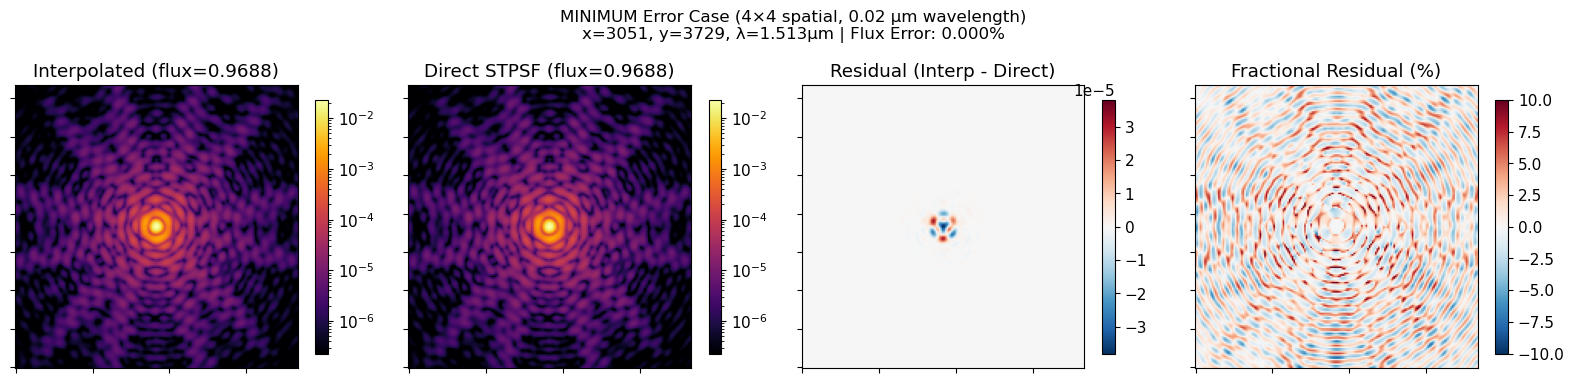

In [91]:
# Plot PSF comparisons for minimum error case
idx = example_indices[0]
plot_psf_comparison(
    payload_config5, x_test[idx], y_test[idx], wl_test[idx],
    DETECTOR, ORDER, FOV_ARCSEC, OVERSAMPLE,
    title=f'MINIMUM Error Case ({CONFIG5_NAME})'
)

Attempted to get aberrations at wavelength 9.2e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.2e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.2e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.2e-07 outside the range of the reference data; clipping to closest wavelength 1e-06
Attempted to get aberrations at wavelength 9.2e-07 outside the range of the reference data; clipping to closest wavelength 1e-06


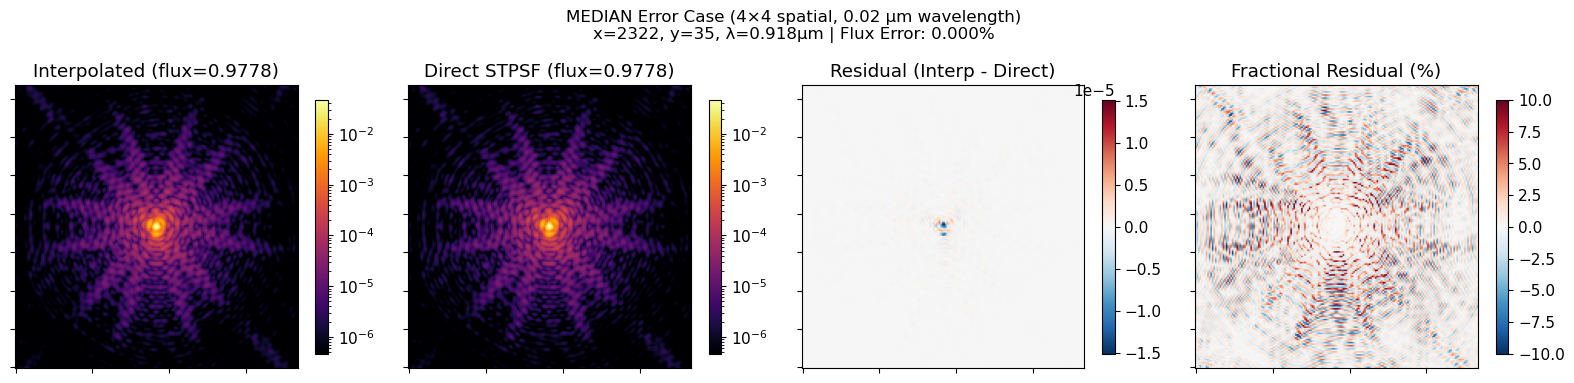

In [92]:
# Plot PSF comparisons for median error case
idx = example_indices[1]
plot_psf_comparison(
    payload_config5, x_test[idx], y_test[idx], wl_test[idx],
    DETECTOR, ORDER, FOV_ARCSEC, OVERSAMPLE,
    title=f'MEDIAN Error Case ({CONFIG5_NAME})'
)

Attempted to get aberrations at field point (3078, 3916) which is outside the range of the reference data; approximating to nearest interpolated point (3077.829354148518, 3572.4899009666424)


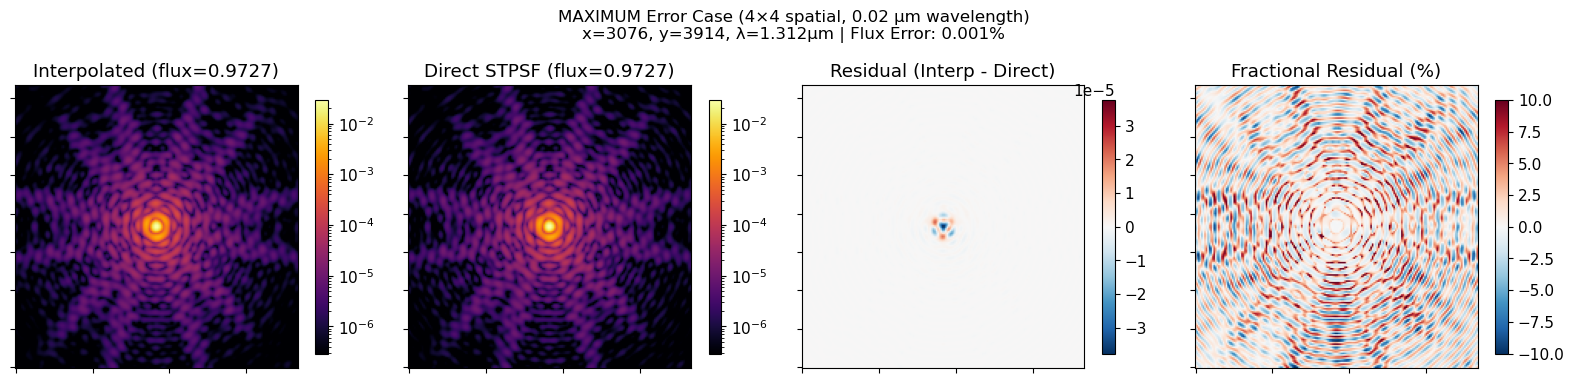

In [93]:
# Plot PSF comparisons for maximum error case
idx = example_indices[2]
plot_psf_comparison(
    payload_config5, x_test[idx], y_test[idx], wl_test[idx],
    DETECTOR, ORDER, FOV_ARCSEC, OVERSAMPLE,
    title=f'MAXIMUM Error Case ({CONFIG5_NAME})'
)

---

# Timing Estimates for All-SCA Validation

Estimate time required to run validation across all 18 SCAs.

In [94]:
# Timing estimates based on this notebook's results
N_SCAS = 18

print("Timing Estimates for All-SCA Validation")
print("="*60)
print(f"\nNumber of SCAs: {N_SCAS}")
print(f"Test points per SCA: {N_TEST_POINTS}")
print()

for name, results, payload, t_gen in all_configs:
    t_val = results['timing']['total']
    t_total_per_sca = t_gen + t_val
    t_all_scas = t_total_per_sca * N_SCAS
    
    print(f"{name}:")
    print(f"  Payload generation: {t_gen/60:.1f} min")
    print(f"  Validation ({N_TEST_POINTS} points): {t_val/60:.1f} min")
    print(f"  Total per SCA: {t_total_per_sca/60:.1f} min")
    print(f"  All {N_SCAS} SCAs: {t_all_scas/60:.1f} min ({t_all_scas/3600:.1f} hours)")
    print()

Timing Estimates for All-SCA Validation

Number of SCAs: 18
Test points per SCA: 128

5×5 spatial, 0.1 μm wavelength:
  Payload generation: 1.8 min
  Validation (128 points): 0.8 min
  Total per SCA: 2.6 min
  All 18 SCAs: 46.4 min (0.8 hours)

5×5 spatial, 0.05 μm wavelength:
  Payload generation: 3.5 min
  Validation (128 points): 0.8 min
  Total per SCA: 4.3 min
  All 18 SCAs: 76.9 min (1.3 hours)

10×10 spatial, 0.1 μm wavelength:
  Payload generation: 7.3 min
  Validation (128 points): 0.8 min
  Total per SCA: 8.1 min
  All 18 SCAs: 145.2 min (2.4 hours)

3×3 spatial, 0.02 μm wavelength:
  Payload generation: 3.1 min
  Validation (128 points): 0.8 min
  Total per SCA: 3.9 min
  All 18 SCAs: 71.0 min (1.2 hours)

4×4 spatial, 0.02 μm wavelength:
  Payload generation: 5.5 min
  Validation (128 points): 0.8 min
  Total per SCA: 6.3 min
  All 18 SCAs: 114.0 min (1.9 hours)



In [95]:
# Final summary table
print("\n" + "="*80)
print("FINAL SUMMARY")
print("="*80)
print(f"\nDetector: {DETECTOR}")
print(f"Order: {ORDER} (GRISM1)")
print(f"FOV: {FOV_ARCSEC} arcsec")
print(f"Oversample: {OVERSAMPLE}×")
print(f"Test points: {N_TEST_POINTS} (Sobol sequence)")
print()
print(comparison_df.to_string(index=False))


FINAL SUMMARY

Detector: WFI02
Order: 1 (GRISM1)
FOV: 5.0 arcsec
Oversample: 4×
Test points: 128 (Sobol sequence)

                   Configuration   Grid Shape Memory (MB) Gen Time (min) Mean Flux Err (%) Max Flux Err (%) Median Flux Err (%) Interp Speed (ms)
  5×5 spatial, 0.1 μm wavelength   (12, 5, 5)        40.6            1.8            0.0036           0.0122              0.0026              3.70
 5×5 spatial, 0.05 μm wavelength   (23, 5, 5)        77.9            3.5            0.0012           0.0042              0.0009              4.48
10×10 spatial, 0.1 μm wavelength (12, 10, 10)       162.5            7.3            0.0036           0.0122              0.0026              4.07
 3×3 spatial, 0.02 μm wavelength   (56, 3, 3)        68.3            3.1            0.0003           0.0013              0.0002              5.80
 4×4 spatial, 0.02 μm wavelength   (56, 4, 4)       121.3            5.5            0.0003           0.0013              0.0002              5.53
